In [1]:
# 这个Python 3环境自带许多有用的分析库
# 由kaggle/python Docker镜像定义：https://github.com/kaggle/docker-python
# 例如，这里有几个有用的包可以加载

import numpy as np # 线性代数
import pandas as pd # 数据处理，CSV文件I/O（例如 pd.read_csv）

# 输入数据文件位于只读的"../input/"目录中
# 例如，运行以下代码（点击运行或按Shift+Enter）将列出输入目录下的所有文件

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 你可以向当前目录（/kaggle/working/）写入最多20GB的数据，当你使用"Save & Run All"创建版本时，这些数据将作为输出保留
# 你也可以将临时文件写入/kaggle/temp/，但它们不会在当前会话之外被保存

In [2]:
import matplotlib.pyplot as plt

# ===================== 全局中文&学术样式配置 =====================
plt.rcParams["font.family"] = ["SimHei",]  # 兼容Windows/Linux/Mac
plt.rcParams["axes.unicode_minus"] = False  # 负号正常显示
plt.rcParams["font.size"] = 12              # 基础字号
plt.rcParams["axes.titlesize"] = 14         # 标题字号
plt.rcParams["axes.labelsize"] = 12          # 坐标轴标签
plt.rcParams["xtick.labelsize"] = 10         # 刻度字号
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10         # 图例字号
plt.rcParams["figure.dpi"] = 300            # 屏幕渲染分辨率
plt.rcParams["figure.figsize"] = (6, 4)     # 论文标准图尺寸（单栏）
plt.rcParams["axes.spines.top"] = False     # 隐藏上边框
plt.rcParams["axes.spines.right"] = False   # 隐藏右边框
plt.rcParams["lines.linewidth"] = 1.5       # 线条粗细
plt.rcParams["lines.markersize"] = 4        # 标记大小
plt.rcParams["grid.alpha"] = 0.3            # 网格透明度
# =================================================================

# 🍀 移动应用分析项目：留存率分析、A/B测试与主题活动评估

## 项目介绍与目标

### 介绍
在快速发展的移动游戏市场中，公司不断努力改进其应用以吸引和留住用户。成功的关键因素之一是理解用户行为、分析促销优惠的有效性以及评估已举办主题活动的结果。本分析报告旨在基于所提供的数据，对移动应用的几个重要方面进行全面分析。

### 项目目标

1. **留存率指标分析**：
   - 编写一个用于计算留存率的函数，以评估应用在留住用户方面的成功程度。

2. **A/B测试结果评估**：
   - 分析不同促销方案A/B测试的数据结果。
   - 使用适当的指标确定哪个方案是最佳的，以做出明智的决策。

3. **游戏主题活动评估**：
   - 提出并论证一套用于评估最近一次游戏主题活动结果的指标，以了解其对用户活跃度和游戏整体指标的影响。

### 假设：
- **H₀：测试组与对照组之间没有统计学显著差异。**
- **H₁：测试组的结果在统计学上显著高于对照组。**

# ❄️ 阶段1：数据加载与预处理

## 🍇 导入所有需要的Python库

In [3]:
# 数据操作与分析
import pandas as pd
import numpy as np
import datetime
from typing import List, Dict, Set
from scipy.stats import (
    ttest_ind,
    norm,
    chi2_contingency,
    mannwhitneyu
)

# 数据可视化
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.ticker as mtick

# 统计分析
from scipy import stats

# HTTP请求
import requests

# URL编码参数
from urllib.parse import urlencode

In [4]:
# 为每个文件创建DataFrame
reg_data = pd.read_csv('reg_data.csv', delimiter=';')
auth_data = pd.read_csv('auth_data.csv', delimiter=';')
ab_test = pd.read_csv('ab_test.csv', delimiter=';')

# 数据检查
print(reg_data.head())
print(auth_data.head())
print(ab_test.head())

      reg_ts  uid
0  911382223    1
1  932683089    2
2  947802447    3
3  959523541    4
4  969103313    5
     auth_ts  uid
0  911382223    1
1  932683089    2
2  932921206    2
3  933393015    2
4  933875379    2
   user_id  revenue testgroup
0        1        0         b
1        2        0         a
2        3        0         a
3        4        0         b
4        5        0         b


数据已成功加载并处理)))

In [5]:
# 检查每个dataframe各列中的空值
print(reg_data.isnull().sum())
print(auth_data.isnull().sum())
print(ab_test.isnull().sum())

reg_ts    0
uid       0
dtype: int64
auth_ts    0
uid        0
dtype: int64
user_id      0
revenue      0
testgroup    0
dtype: int64


所有dataframe中均无空值

In [6]:
# 查看dataframe的特征
print(reg_data.info())
print(auth_data.info())
print(ab_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB
None


## 🎃 数据评估

分析数据以三个独立的数据集提供，每个数据集包含应用不同方面的信息。以下是每个数据集的特征描述：

1. **用户注册数据（reg_data）**：
   - **记录数量**：1,000,000
   - **列**：
     - `reg_ts`（Unix时间格式的注册时间，数据类型`int64`）
     - `uid`（用户唯一标识符，数据类型`int64`）
   - **内存占用**：15.3 MB
   - **描述**：此数据集包含用户注册时间的信息。所有数据完整填写，无缺失值。

2. **用户活动数据（auth_data）**：
   - **记录数量**：9,601,013
   - **列**：
     - `auth_ts`（Unix时间格式的认证时间，数据类型`int64`）
     - `uid`（用户唯一标识符，数据类型`int64`）
   - **内存占用**：146.5 MB
   - **描述**：此数据集包含用户认证时间的信息。所有数据完整填写，无缺失值。

3. **A/B测试数据（ab_test）**：
   - **记录数量**：404,770
   - **列**：
     - `user_id`（用户唯一标识符，数据类型`int64`）
     - `revenue`（收入，数据类型`int64`）
     - `testgroup`（测试分组，数据类型`object`）
   - **内存占用**：9.3+ MB
   - **描述**：此数据集包含A/B测试结果的信息，包括每个用户的收入和测试分组。所有数据完整填写，无缺失值。

总体而言，数据质量良好，可以进行进一步分析和提取有用的洞察。

# ❄️ 阶段2：通用数据分析

将所有dataframe转换为便于使用的格式

### 数据转换

In [7]:
# 将reg_ts列转换为datetime64[ns]并创建单独的日期和时间列
reg_data['date'] = pd.to_datetime(reg_data['reg_ts'], unit='s').dt.date
reg_data['date'] = pd.to_datetime(reg_data['date'], errors='coerce')
reg_data['time'] = pd.to_datetime(reg_data['reg_ts'], unit='s').dt.strftime('%H:%M:%S')

# 删除reg_ts列
reg_data.drop('reg_ts', axis=1, inplace=True)

# 检查
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   uid     1000000 non-null  int64         
 1   date    1000000 non-null  datetime64[ns]
 2   time    1000000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 22.9+ MB


转换成功完成。

由于reg_ts是Unix时间，为方便起见，创建了两个单独的列：日期（date）和时间（time）。

In [8]:
# 将auth_ts列转换为datetime64[ns]并创建单独的日期和时间列
auth_data['date'] = pd.to_datetime(auth_data['auth_ts'], unit='s').dt.date
auth_data['date'] = pd.to_datetime(auth_data['date'], errors='coerce')
auth_data['time'] = pd.to_datetime(auth_data['auth_ts'], unit='s').dt.strftime('%H:%M:%S')

# 删除auth_ts列
auth_data.drop('auth_ts', axis=1, inplace=True)

# 检查
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 3 columns):
 #   Column  Dtype         
---  ------  -----         
 0   uid     int64         
 1   date    datetime64[ns]
 2   time    object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 219.7+ MB


转换成功完成。

由于auth_ts是Unix时间，为方便起见，创建了两个单独的列：日期（date）和时间（time）。

### 开始逐步了解数据

In [9]:
# reg_data和auth_data中的年份
reg = list(reg_data['date'].dt.year)
auth = list(auth_data['date'].dt.year)

print(f'reg_data  = {set(reg)}')
print(f'auth_data = {set(auth)}')

reg_data  = {1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020}
auth_data = {1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020}


文件中包含1998年至2020年的记录。

In [10]:
"""
检查reg_data中的UID值是否严格按升序排列。
如果值是有序的，则返回True，否则返回False。
不检查auth_data中的值，因为任何玩家都可以随时登录游戏。
"""

def is_sorted_ascending(column: List[int]) -> bool:
    """
    检查column列表中的数字是否严格按升序排列。

    参数：
    column (List[int])：要检查的数字列表。

    返回：
    bool：如果数字按升序排列则为True，否则为False。
    """
    return all(column[i] <= column[i + 1] for i in range(len(column) - 1))

# 检查'uid'列
result_reg = is_sorted_ascending(reg_data['uid'])

# 输出结果
print(result_reg)

True


uid按顺序排列

In [11]:
"""
检查注册数据和认证数据中的唯一用户数量。
预计总共应有1,000,000个唯一玩家。
"""

# 数据检查
f1 = list(reg_data['uid']) 
g1 = list(auth_data['uid']) 

print(len(set(f1)))
print(len(set(g1)))

1000000
1000000


用户数量各为100万，无损失或多余。

In [12]:
# 查看auth_data和reg_data中的最大和最小日期
print(f'auth_data\n最大日期：{auth_data.date.max()}\n最小日期：{auth_data.date.min()}\n')
print(f'reg_data\n最大日期：{reg_data.date.max()}\n最小日期：{reg_data.date.min()}')

auth_data
最大日期：2020-09-23 00:00:00
最小日期：1998-11-18 00:00:00

reg_data
最大日期：2020-09-23 00:00:00
最小日期：1998-11-18 00:00:00


我们确定了每个文件中的第一条和最后一条记录。两个文件中的第一条和最后一条记录相同。

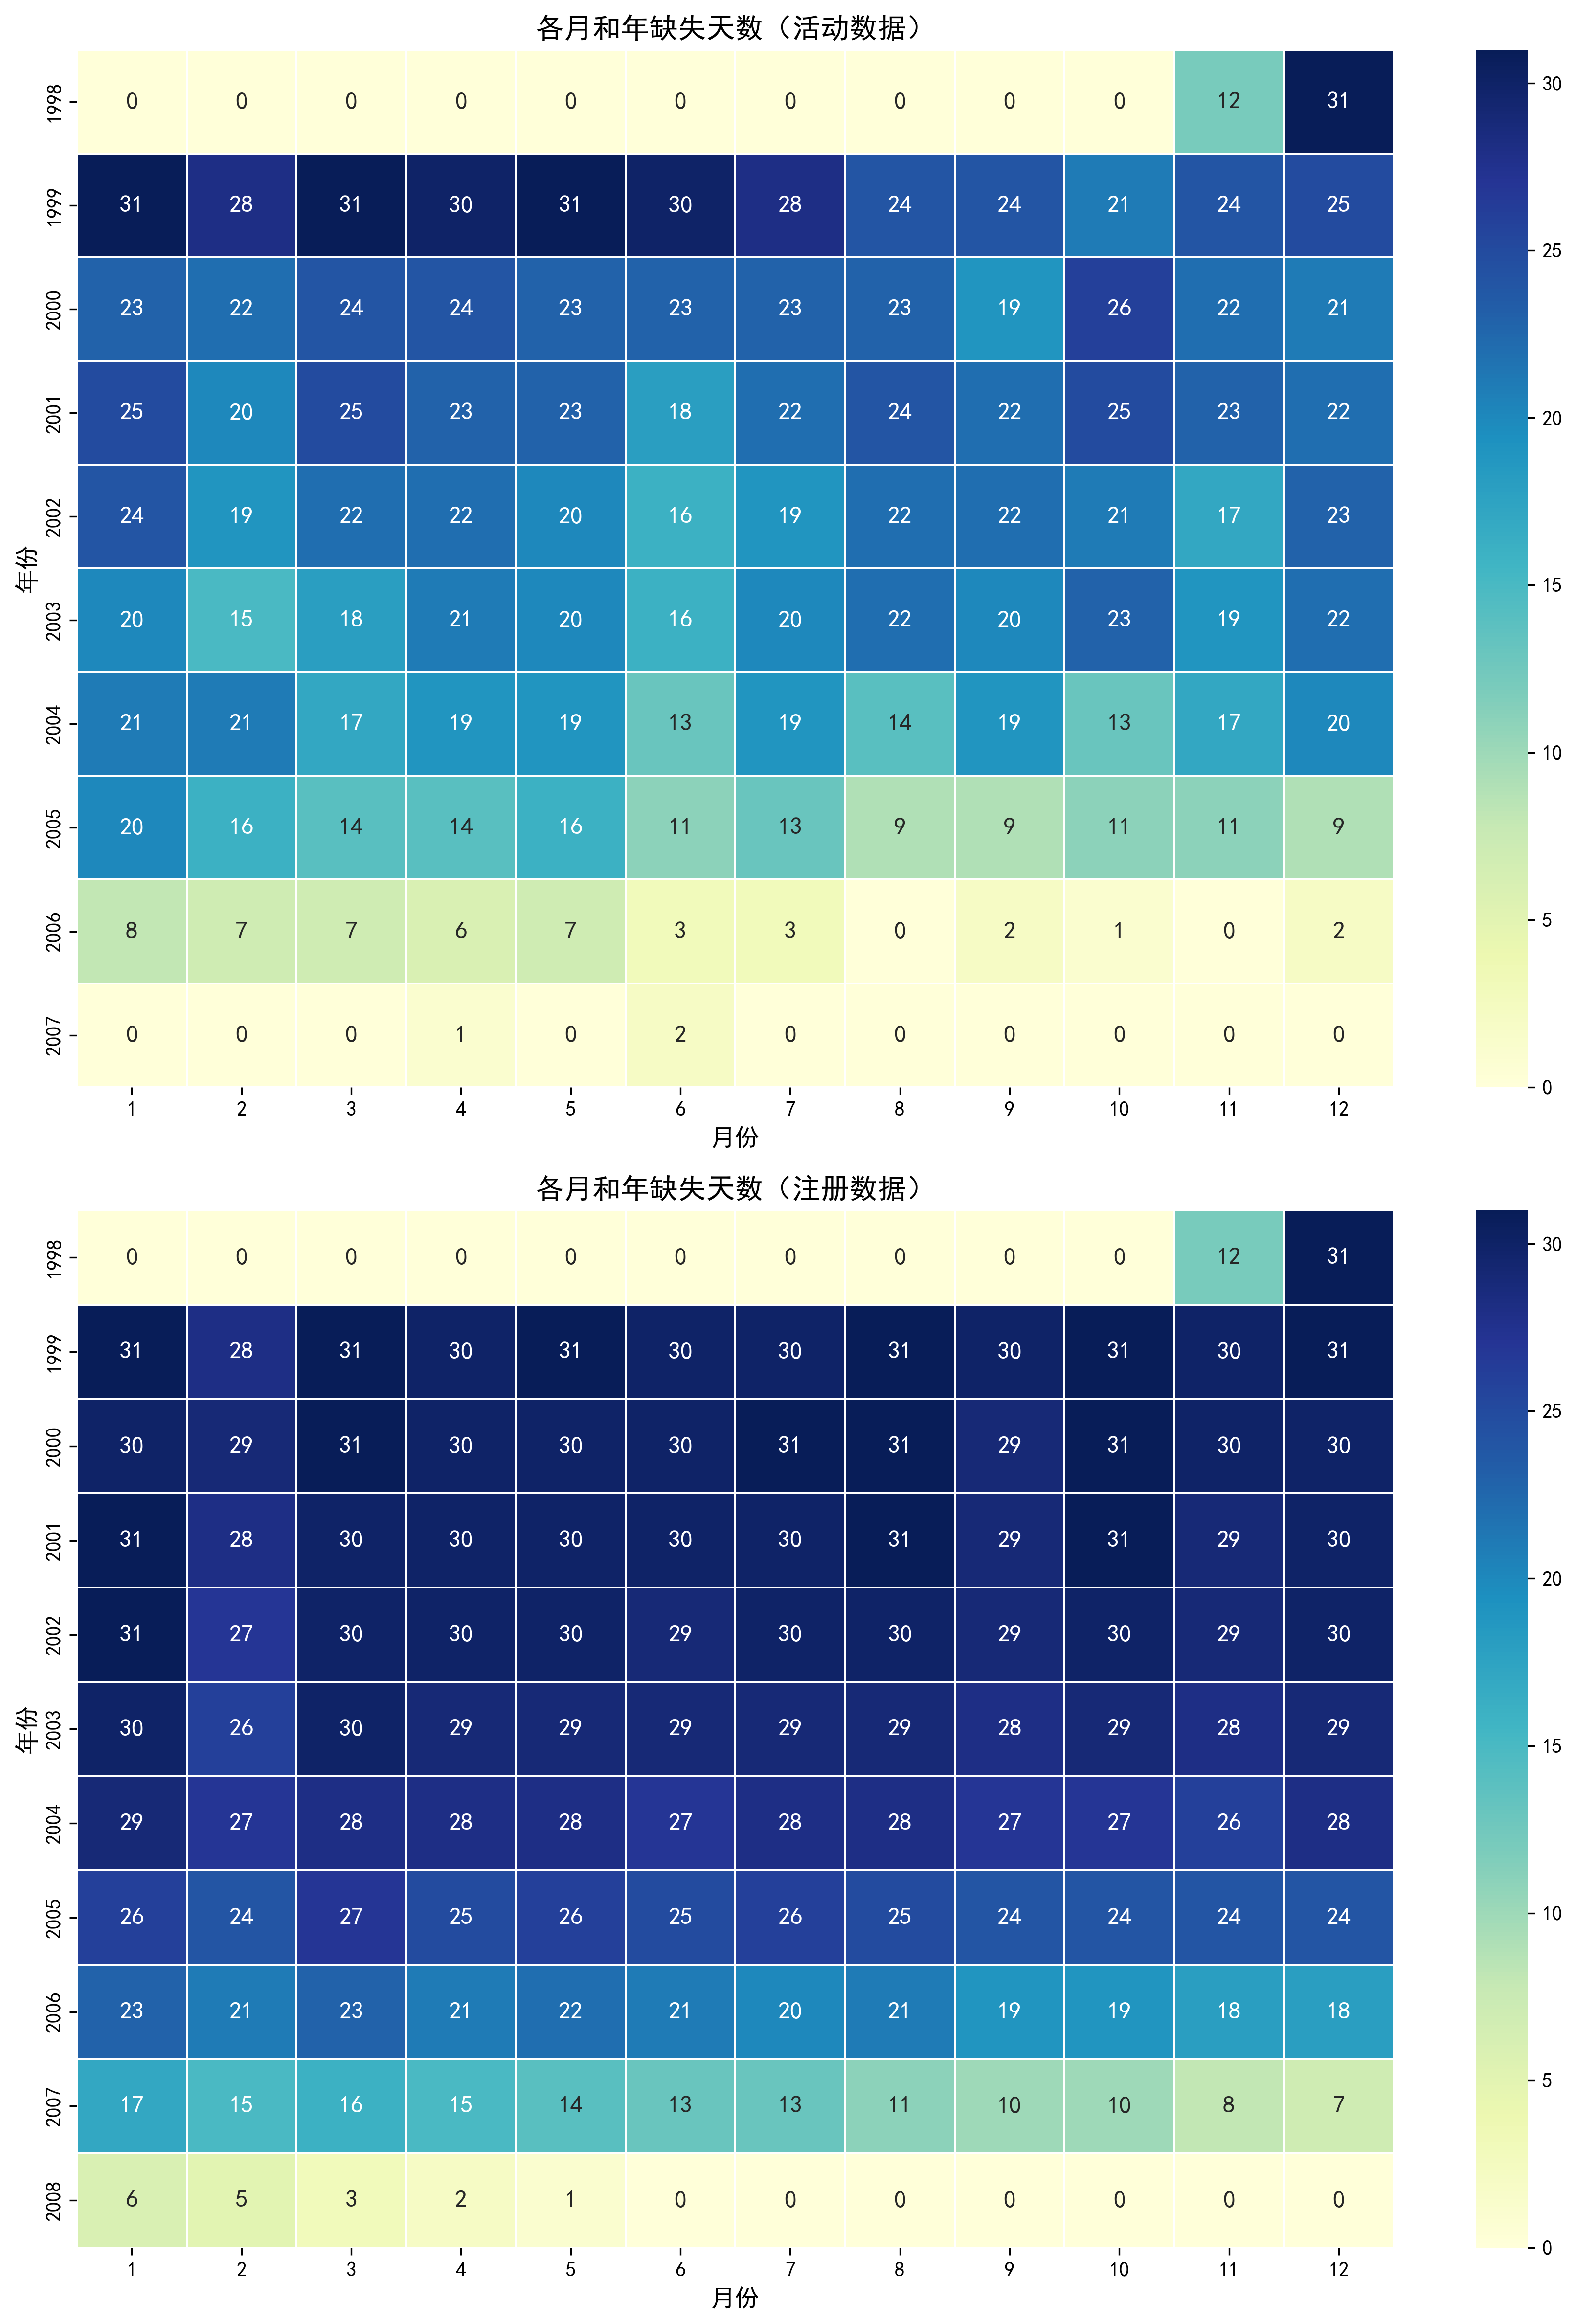

活动的最后缺失日期：2007-06-26 00:00:00
注册的最后缺失日期：2008-05-14 00:00:00


In [13]:
"""
查看玩家活动：
1) 输出关于"缺失天数"的热力图。
2) 确定游戏何时开始流行。

可视化认证数据（auth_data）和注册数据（reg_data）。
同时输出两个DataFrame的最后"年-月-日"不活跃（缺失）日。

这将有助于理解游戏何时开始流行。
"""

def missed_dates(df_data: pd.DataFrame, date_col: str, start_date: str = '1998-11-18', end_date: str = '2020-09-23'):
    """
    查找数据中的缺失日期，并返回按年和月统计的缺失天数以及最后一个缺失日期。

    参数：
    df_data (pd.DataFrame)：包含日期列的DataFrame数据。
    date_col (str)：日期列的名称。
    start_date (str)：分析起始日期（格式为'YYYY-MM-DD'）。
    end_date (str)：分析结束日期（格式为'YYYY-MM-DD'）。

    返回：
    Tuple[pd.DataFrame, pd.Timestamp]：按年和月统计的缺失天数，以及最后一个缺失日期。
    """
    # 将日期列转换为datetime格式
    df_data[date_col] = pd.to_datetime(df_data[date_col])
    
    # 筛选指定日期范围内的数据
    df_data_filtered = df_data[(df_data[date_col] >= start_date) & (df_data[date_col] <= end_date)]
    
    # 添加年、月、日列
    df_data_filtered['year'] = df_data_filtered[date_col].dt.year
    df_data_filtered['month'] = df_data_filtered[date_col].dt.month
    df_data_filtered['day'] = df_data_filtered[date_col].dt.day
    
    # 创建完整日期范围的DataFrame
    full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    full_date_df = pd.DataFrame(full_date_range, columns=['date'])
    
    # 为完整日期范围添加年、月、日列
    full_date_df['year'] = full_date_df['date'].dt.year
    full_date_df['month'] = full_date_df['date'].dt.month
    full_date_df['day'] = full_date_df['date'].dt.day
    
    # 检查缺失日期
    merged_data = full_date_df.merge(df_data_filtered, how='left', left_on=['year', 'month', 'day'], right_on=['year', 'month', 'day'], suffixes=('', '_auth'))
    missing_dates = merged_data[merged_data[date_col + '_auth'].isnull()]['date']
    
    # 为缺失日期数据添加年和月列
    missing_dates_df = pd.DataFrame(missing_dates, columns=['date'])
    missing_dates_df['year'] = missing_dates_df['date'].dt.year
    missing_dates_df['month'] = missing_dates_df['date'].dt.month
    
    # 按年和月统计缺失天数
    missing_count = missing_dates_df.groupby(['year', 'month']).size().unstack(fill_value=0)
    
    # 最后一个缺失日期
    last_missing_date = missing_dates.max() if not missing_dates.empty else None
    
    return missing_count, last_missing_date

# 将日期列转换为datetime格式
auth_data['date'] = pd.to_datetime(auth_data['date'])
reg_data['date'] = pd.to_datetime(reg_data['date'])

# 获取认证和注册的数据
missing_count_auth, last_missing_auth_date = missed_dates(auth_data, 'date')
missing_count_reg, last_missing_reg_date = missed_dates(reg_data, 'date')

# 绘制图表
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# 认证数据缺失天数的可视化
sns.heatmap(missing_count_auth, cmap='YlGnBu', linewidths=.5, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('各月和年缺失天数（活动数据）')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('年份')

# 注册数据缺失天数的可视化
sns.heatmap(missing_count_reg, cmap='YlGnBu', linewidths=.5, annot=True, fmt='d', ax=axes[1])
axes[1].set_title('各月和年缺失天数（注册数据）')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('年份')

plt.tight_layout()
plt.show()

# 输出认证和注册的最后缺失日期
print(f"活动的最后缺失日期：{last_missing_auth_date}")
print(f"注册的最后缺失日期：{last_missing_reg_date}")

#### 认证缺失天数
- 1999年至2006年期间观察到最大的缺失天数。
- 2007年缺失天数显著减少。
- 最后缺失的认证日期：2007-06-26。
#### 注册缺失天数
- 1999年至2007年期间，与认证数据类似，观察到大量缺失天数。
- 2004年和2005年记录了最大的缺失天数。
- 最后缺失的注册日期：2006-05-31。

### 🌴 UID和user_id是什么？

#### 数据可视化分析中首先遇到的问题：

- ##### *reg_data列表中是否有管理员UID？*
- ##### *ab_test.user_id是用户UID吗？*

我们将进行分析以回答这些问题。

#### 🍬 reg_data列表中是否有管理员UID？

考虑几个重要事实：
- 在类Unix操作系统中，用户通过用户标识符（UID）进行标识
- 根据约定，UID 1至100保留用于系统需求；一些指南建议保留UID 101至499（Red Hat）甚至999（Debian）。

In [14]:
"""
该函数计算缺失的UID数量。
UID按顺序编号，每个新用户分配+1。
"""

def find_missing_numbers(column: List[int]) -> List[int]:
    """
    在列中查找缺失的数字，假设数字应从最小值到最大值顺序排列。

    参数：
    column (List[int])：需要查找缺失值的数字列表。

    返回：
    List[int]：排序的缺失数字列表。
    """
    min_val = column.min()
    max_val = column.max()
    full_range = set(range(min_val, max_val + 1))
    actual_numbers = set(column)
    missing_numbers = sorted(full_range - actual_numbers)
    return missing_numbers

# 检查'number'列
missing_numbers_reg_data = find_missing_numbers(reg_data['uid'])

# 检查'number'列
missing_numbers_auth = find_missing_numbers(auth_data['uid'])

# 检查'number'列
missing_numbers_ab_test = find_missing_numbers(ab_test['user_id'])

# 输出结果
print(len(missing_numbers_auth))
print(len(missing_numbers_reg_data))
print(len(missing_numbers_ab_test))

110622
110622
0


reg_data和auth_data中缺失的uid数量相同，而ab_test中没有缺失的uid。

In [15]:
"""
如果有管理员绑定的UID，它们应该在reg_data中
只检查missing_numbers_reg_data
"""

# 通过UID中的大间隔搜索管理员
missing_numbers = list(missing_numbers_reg_data)

# 创建新列表，计算与前一个数的差值并取绝对值
differences = [abs(missing_numbers[i] - missing_numbers[i-1]) for i in range(1, len(missing_numbers))]

# 输出结果
for i in differences:
    if i>99:
        print(i)

105
124
106
101


连续缺失的最大uid数量为124，但无法确定这个区间就是分配给管理员的uid。

#### 🎃 总结：
- 共有110,622个玩家uid被删除，原因各不相同：公司政策、玩家不活跃等。由于缺乏足够的信息，我们假设某些uid的缺失与玩家或公司删除玩家账户有关，且数据被完全清除。
- 无法确定管理员UID或其数量，因为没有遵循0到100的UID保留约定或任何其他保留规则。
- 根据约定，UID 1至100保留用于系统需求；一些指南建议保留UID 101至499（Red Hat）甚至999（Debian）。
- 发现4段长度为101到124的连续缺失UID，但不能断言这些或除UID 0以外的任何其他UID是分配给管理员的。
- 根据独特玩家的增长数量和项目任务：***"假设你在一家开发移动游戏的公司工作。经理带着一系列关于研究移动应用多个方面的任务来找你"***，可以断言游戏开发不止一个人，而是一个团队，其中一些人肯定分配有一定数量的UID。
- 管理员的UID*无论如何不能计入玩家的通用数据库中，它们应该与玩家分开。因此，在我们的数据库中，其中：

    1. reg_data - 玩家注册时间数据。

    2. auth_data - 用户登录游戏的时间数据。

    3. ab_test - A/B测试结果。

  在任何提供的数据库中都不可能有管理员的UID*，因为所有这些数据库都是严格为玩家设计的。任务1中的文本也证实了这一点，其中明确说明reg_data只包含玩家：

  **留存率是公司中最重要的指标之一。你的任务是编写一个函数，用于计算玩家留存率（按玩家注册日期后的天数计算）。**

#### 结论：
提供的文件仅包含玩家的UID。

### 🍁 ab_test.user_id，这是用户UID吗？

In [16]:
"""
合并两个dataframe以确定哪些用户参与了A/B测试
ab_test -> auth_data
ab_test['user_id'] auth_data['auth_ts']
"""

merged_data_reg_data = pd.merge(ab_test, reg_data, left_on='user_id', right_on='uid', how='inner')
merged_data_reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364555 entries, 0 to 364554
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   user_id    364555 non-null  int64         
 1   revenue    364555 non-null  int64         
 2   testgroup  364555 non-null  object        
 3   uid        364555 non-null  int64         
 4   date       364555 non-null  datetime64[ns]
 5   time       364555 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 16.7+ MB


总结：
- 我们看到merged_data_reg_data中只有364,555行，而ab_test中有404,770行。缺失了40,215行

需要进行额外分析：

In [17]:
# 收集唯一的*id列表并计算其数量
list_merged_data_reg_data = list(merged_data_reg_data.user_id.unique())
len_merged_data_reg_data = len(merged_data_reg_data.user_id.unique()) # len_merged_data_reg_data -> 364555

list_ab_test = ab_test.user_id.unique()
len_ab_test =  len(ab_test.user_id.unique()) # len_ab_test -> 404770

# 计算缺失的*id数量
b = set(list_merged_data_reg_data)
n = set(list_ab_test)

m = n - b
m = list(m)
len(m)

40215

- len_merged_data_reg_data中有364,555个唯一玩家。
- len_ab_test中有404,770个唯一玩家。
- 总共看到40,215个不匹配。

继续分析40,215个user_id：

In [18]:
# 根据auth_data检查缺失的id
list_auth_data = list(auth_data.uid.unique())
p = set(list_auth_data)
o = n - p

# 查找列表中不存在的*id
u = set(o) - set(m)
u1 = set(m) - set(o) 

print(len(o))
print(list(u))
print(list(u1))

40215
[]
[]


auth_data中缺失40,215个id

In [19]:
# 检查一小部分数据中id的存在或缺失
print(auth_data.uid.unique()[:20])
print(reg_data.uid.unique()[:20])
print(ab_test.user_id.unique()[:20])

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 20 21]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 20 21]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


可以看到ab_test中缺少第17个user_id

In [20]:
ab_test.groupby('testgroup').size()

testgroup
a    202103
b    202667
dtype: int64

总结：
- ab_test.user_id不等于reg_data.uid或auth_data.uid
- ab_test.user_id中的数据是从1到404,770的顺序计数，没有重复的数字。
- reg_data.uid和auth_data.uid中的数据从较小的uid到较大的uid按顺序排列，但缺少一些uid，例如：...15, 16, 18, 19...缺少17。而在ab_test.user_id中，所有数字严格按顺序排列。
- 无法将ab_test.user_id与具体玩家关联起来，因为ab_test.user_id中有一些*id在reg_data.uid或auth_data.uid中不存在。
- 无法确定A/B测试进行的时期。

# ❄️ 阶段3：任务解决

## 🍂 任务1

任务文本：**留存率是公司中最重要的指标之一。你的任务是编写一个函数，用于计算玩家留存率（按玩家注册日期后的天数计算）**

### reg_data特征
- reg_data - 注册时间数据
- 列的值：

        reg_ts - Unix时间格式的玩家注册时间/日期

        uid - Unix格式的用户标识符

        date - 注册的年-月-日

        time - 注册的小时-分钟-秒
        
- 总共1,000,000个唯一玩家

### 数据探索
在计算留存率之前，先更好地了解数据

###     可视化新玩家的注册数量

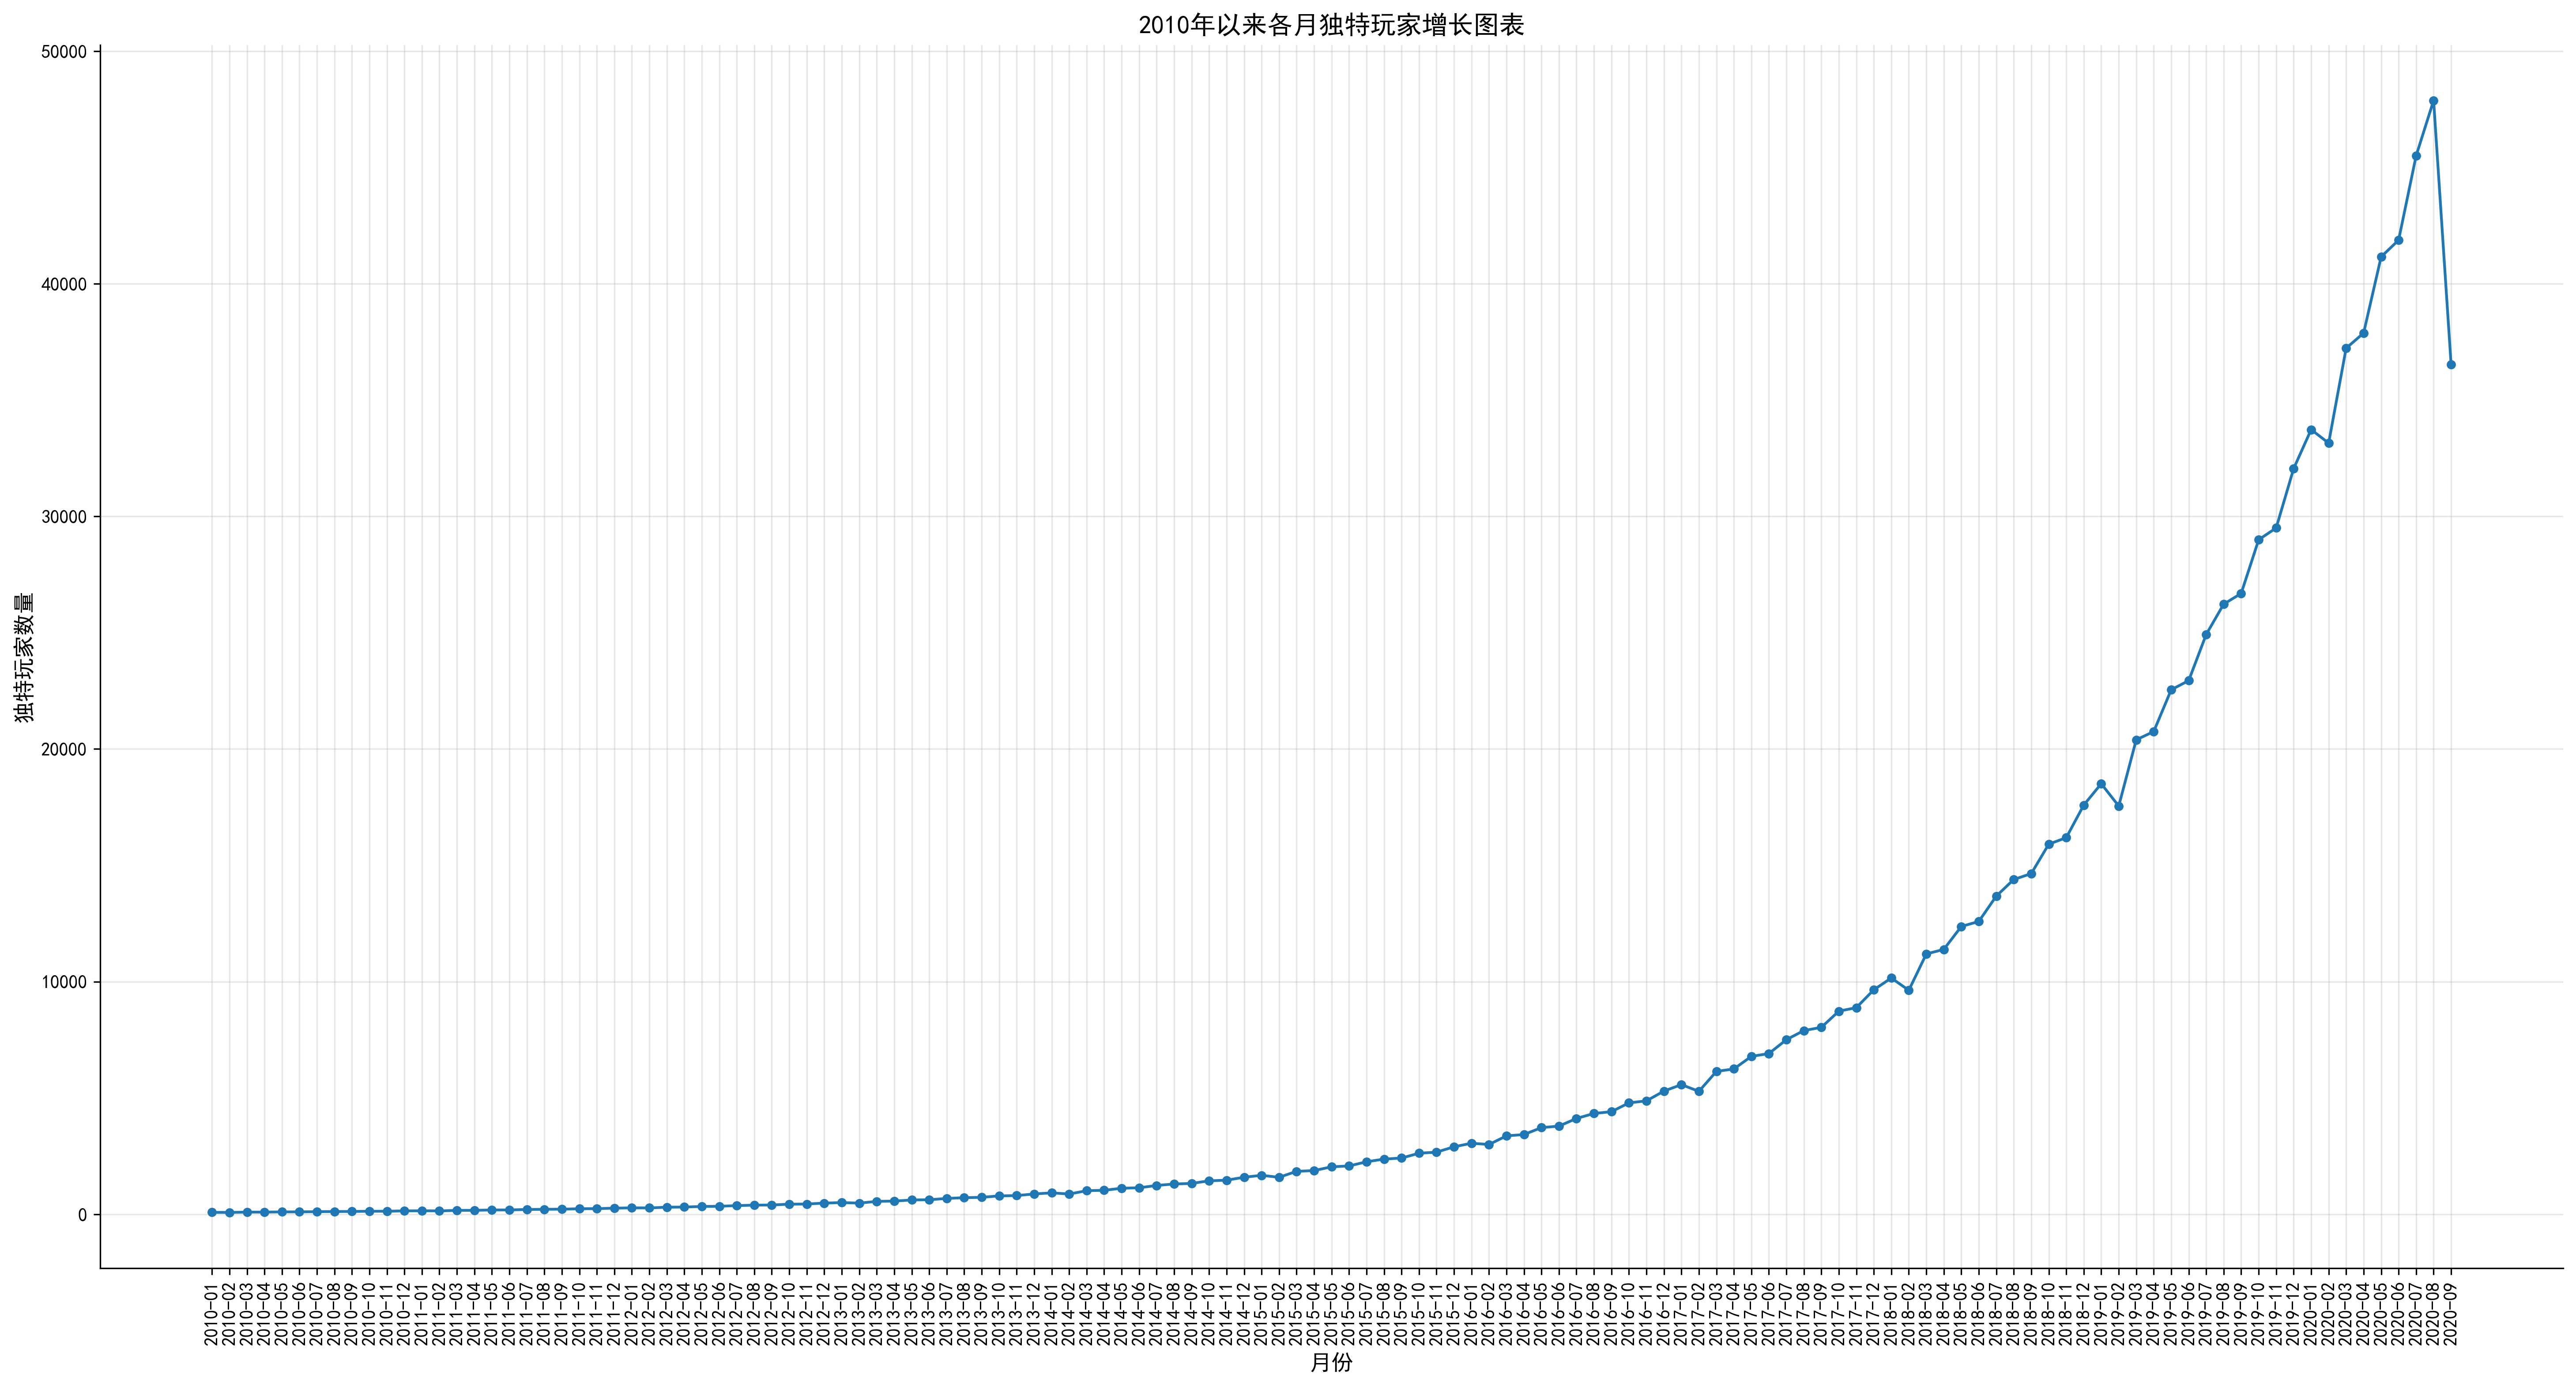

In [21]:
# 添加注册月份列
reg_data['reg_month'] = reg_data['date'].dt.to_period('M')

# 筛选2010年及以后的数据
reg_data_2010 = reg_data[reg_data['date'] >= '2010-01-01']

# 按月份计算唯一用户数量
monthly_growth_2010 = reg_data_2010.groupby('reg_month')['uid'].nunique()

# 绘制2010年以来各月独特玩家增长图表
plt.figure(figsize=(24, 12))
plt.plot(monthly_growth_2010.index.astype(str), monthly_growth_2010.values, marker='o')
plt.title('2010年以来各月独特玩家增长图表')
plt.xlabel('月份')
plt.ylabel('独特玩家数量')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

### 二月

二月份独特用户增长放缓可能由多种因素导致，但合理的解释是二月是最短的月份。这自然会因天数较少而导致注册量减少。
让我们检查各月平均每天的注册数量。

In [22]:
# 将日期列转换为datetime格式
reg_data['date'] = pd.to_datetime(reg_data['date'])

# 从日期列中提取年份和月份
reg_data['year'] = reg_data['date'].dt.year
reg_data['month'] = reg_data['date'].dt.month

# 按年份和月份分组，计算注册数量
monthly_registrations = reg_data.groupby(['year', 'month']).size().reset_index(name='registrations')

# 计算每月平均天数（考虑闰年）
days_in_month = {
    1: 31, 2: 28.25, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# 添加每月天数列
monthly_registrations['days_in_month'] = monthly_registrations['month'].apply(lambda x: days_in_month[x])

# 计算日均注册量
monthly_registrations['avg_registrations_per_day'] = monthly_registrations['registrations'] / monthly_registrations['days_in_month']

# 筛选二月份的数据
february_registrations = monthly_registrations[monthly_registrations['month'] == 2]

# 输出所有月份和二月份的数据
print("所有月份：")
print(monthly_registrations)
print("\n二月：")
print(february_registrations)

# 比较二月与其他月份的日均注册量
mean_february_registrations = february_registrations['avg_registrations_per_day'].mean()
mean_other_months_registrations = monthly_registrations[monthly_registrations['month'] != 2]['avg_registrations_per_day'].mean()

print(f"\n二月日均注册量：{mean_february_registrations:.2f}")
print(f"其他月份日均注册量：{mean_other_months_registrations:.2f}")

if mean_february_registrations < mean_other_months_registrations:
    print("\n二月出现趋势下降。")
else:
    print("\n二月未出现趋势下降。")

所有月份：
     year  month  registrations  days_in_month  avg_registrations_per_day
0    1998     11              1           30.0                   0.033333
1    1999      7              1           31.0                   0.032258
2    2000      1              1           31.0                   0.032258
3    2000      5              1           31.0                   0.032258
4    2000      9              1           30.0                   0.033333
..    ...    ...            ...            ...                        ...
230  2020      5          41159           31.0                1327.709677
231  2020      6          41880           30.0                1396.000000
232  2020      7          45502           31.0                1467.806452
233  2020      8          47882           31.0                1544.580645
234  2020      9          36540           30.0                1218.000000

[235 rows x 5 columns]

二月：
     year  month  registrations  days_in_month  avg_registrations_per_day
12 

### 数据结论

二月日均注册量：134.41

其他月份日均注册量：140.25

### 解读

基于这些数据可以得出以下结论：

- 二月确实出现了注册趋势下降。二月日均注册量（134.41）低于其他月份（140.25）。

### 2020年9月
我们看到这个月出现了急剧下降，为了找出原因，让我们更仔细地查看这个月。

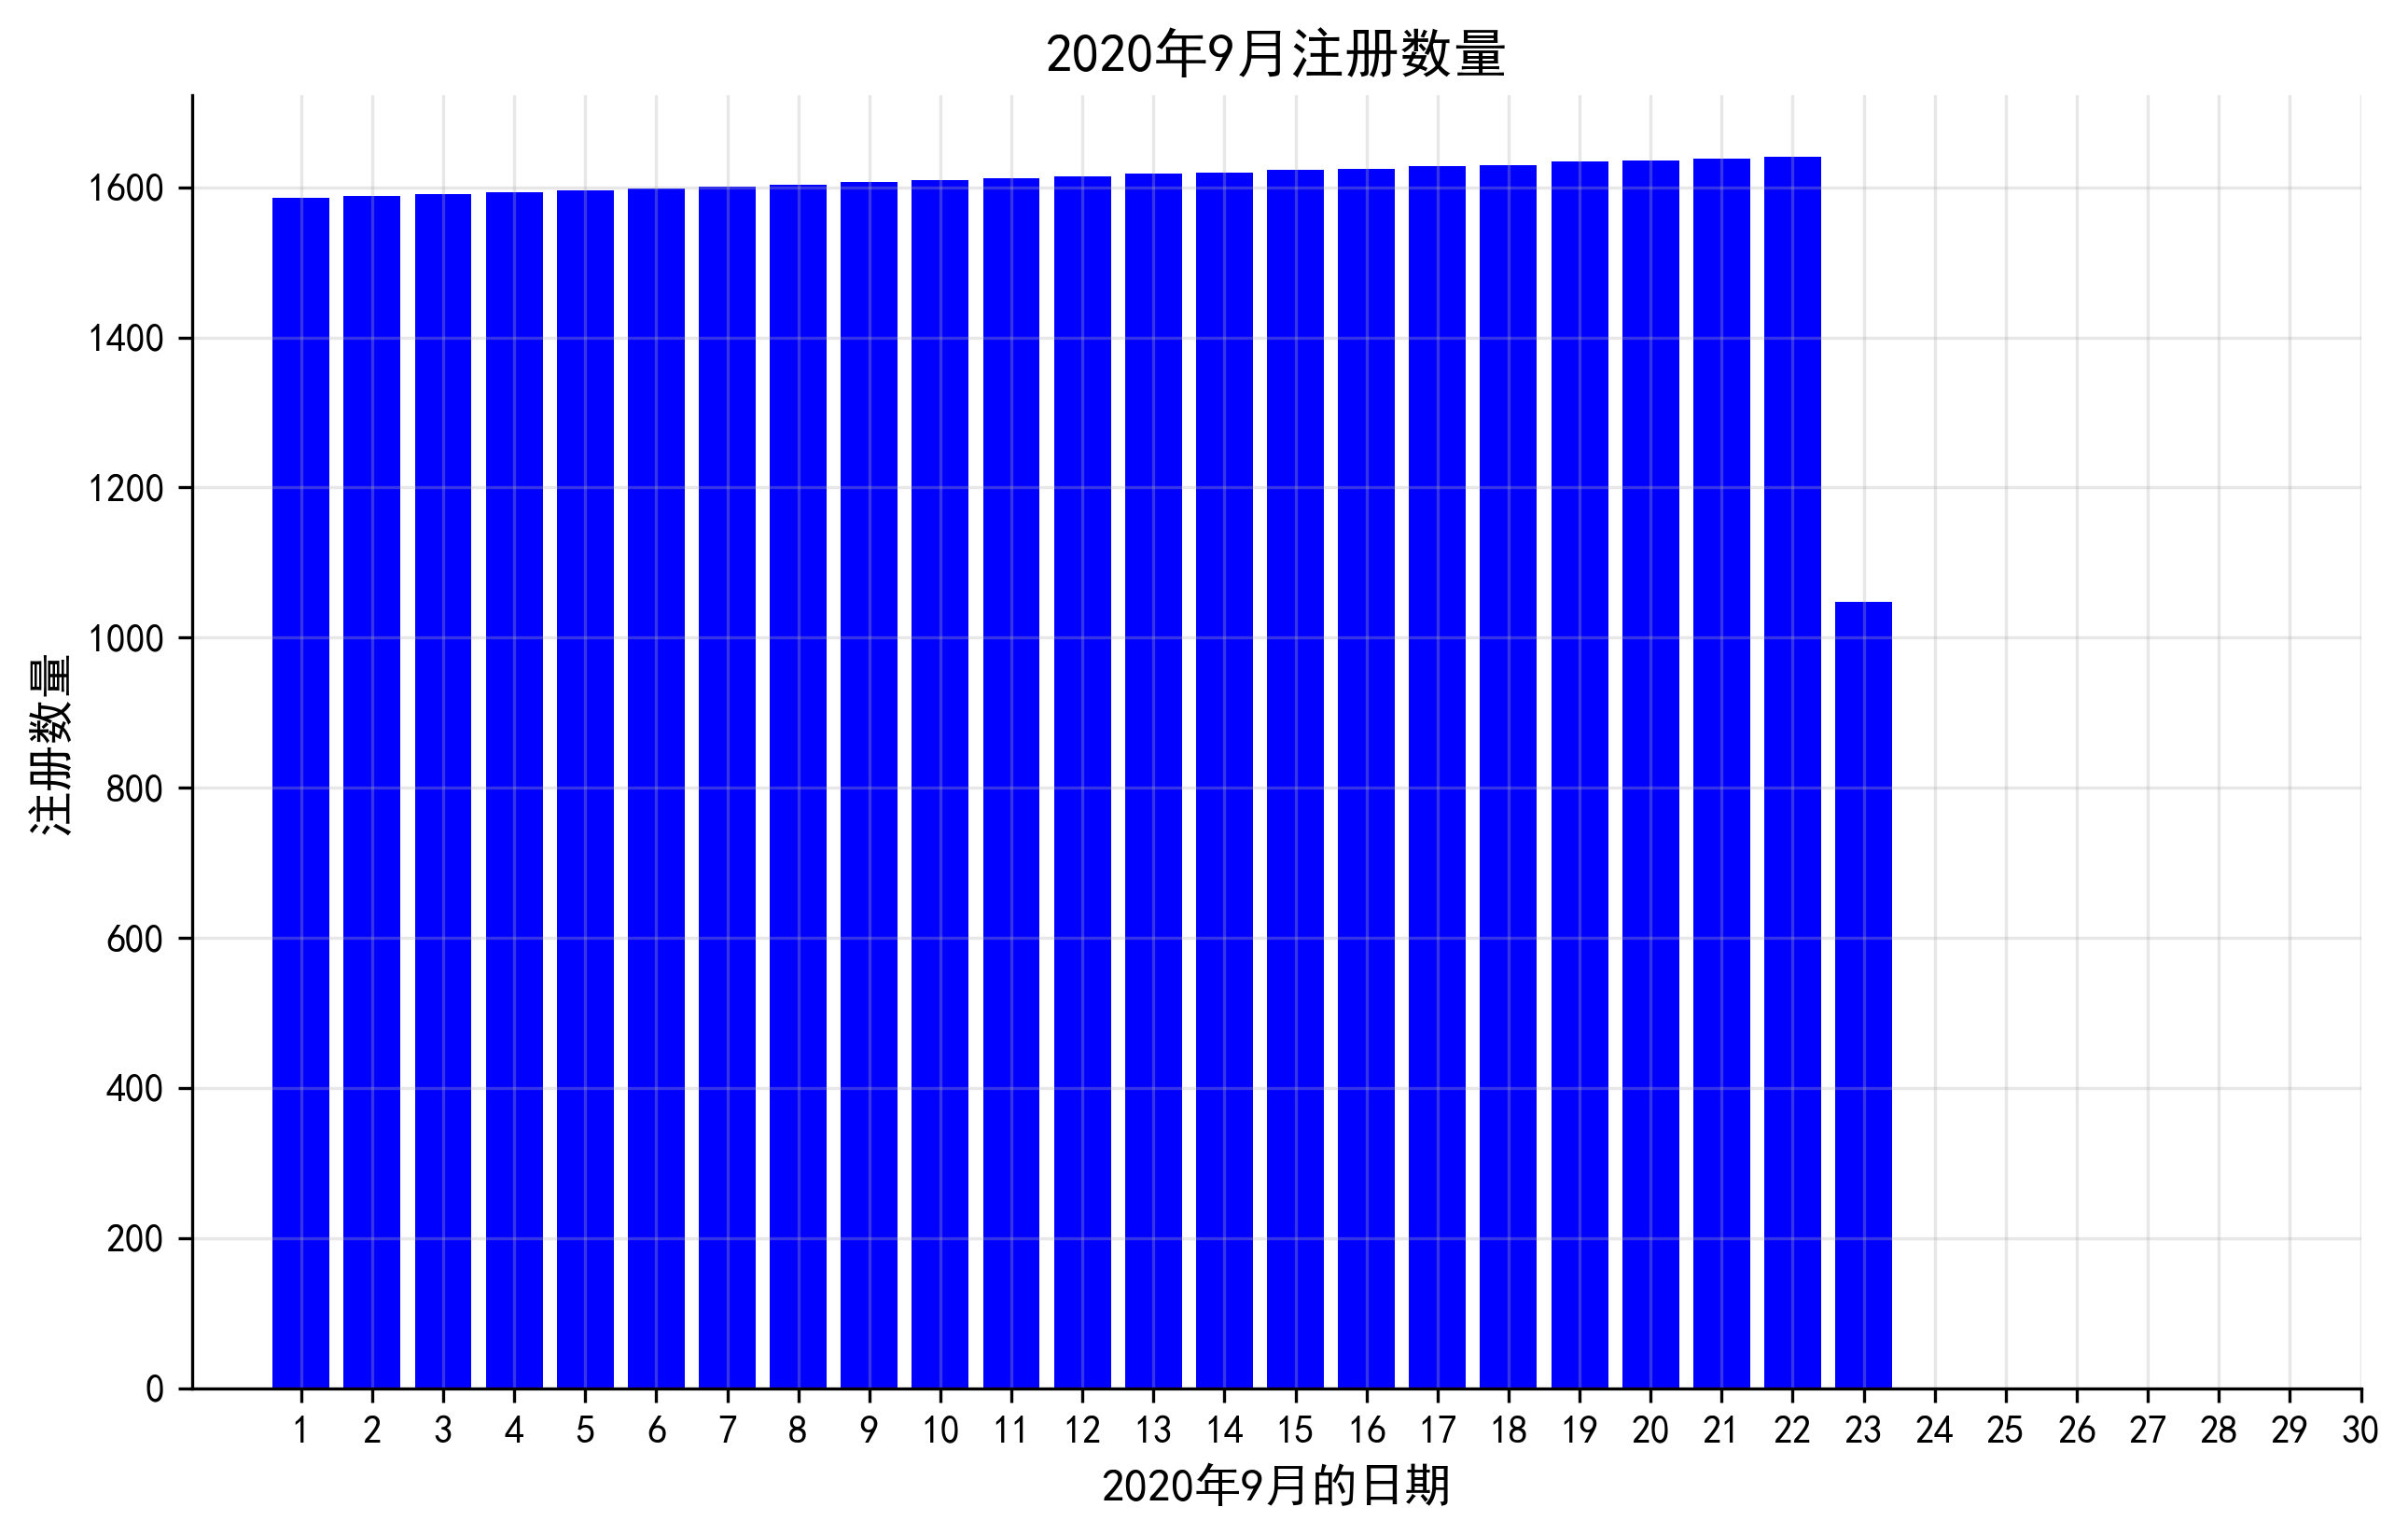

In [23]:
# 将'date'列转换为datetime格式
reg_data['date'] = pd.to_datetime(reg_data['date'])

# 筛选2020年9月的数据
sept_2020_data = reg_data[(reg_data['date'] >= '2020-09-01') & (reg_data['date'] <= '2020-09-30')]

# 按日统计注册数量
registrations_per_day = sept_2020_data['date'].dt.day.value_counts().sort_index()

# 绘制图表
plt.figure(figsize=(10, 6))
plt.bar(registrations_per_day.index, registrations_per_day.values, color='blue')
plt.xlabel('2020年9月的日期')
plt.ylabel('注册数量')
plt.title('2020年9月注册数量')
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

### 总结

这个月数据不完整。分析数据时我发现，我们数据集中的最大注册日期是2020年9月23日。在补充图表中可以看到23日之后注册数量急剧下降。然而，这种下降并不显著，因为它只涉及众多日期中的一天。

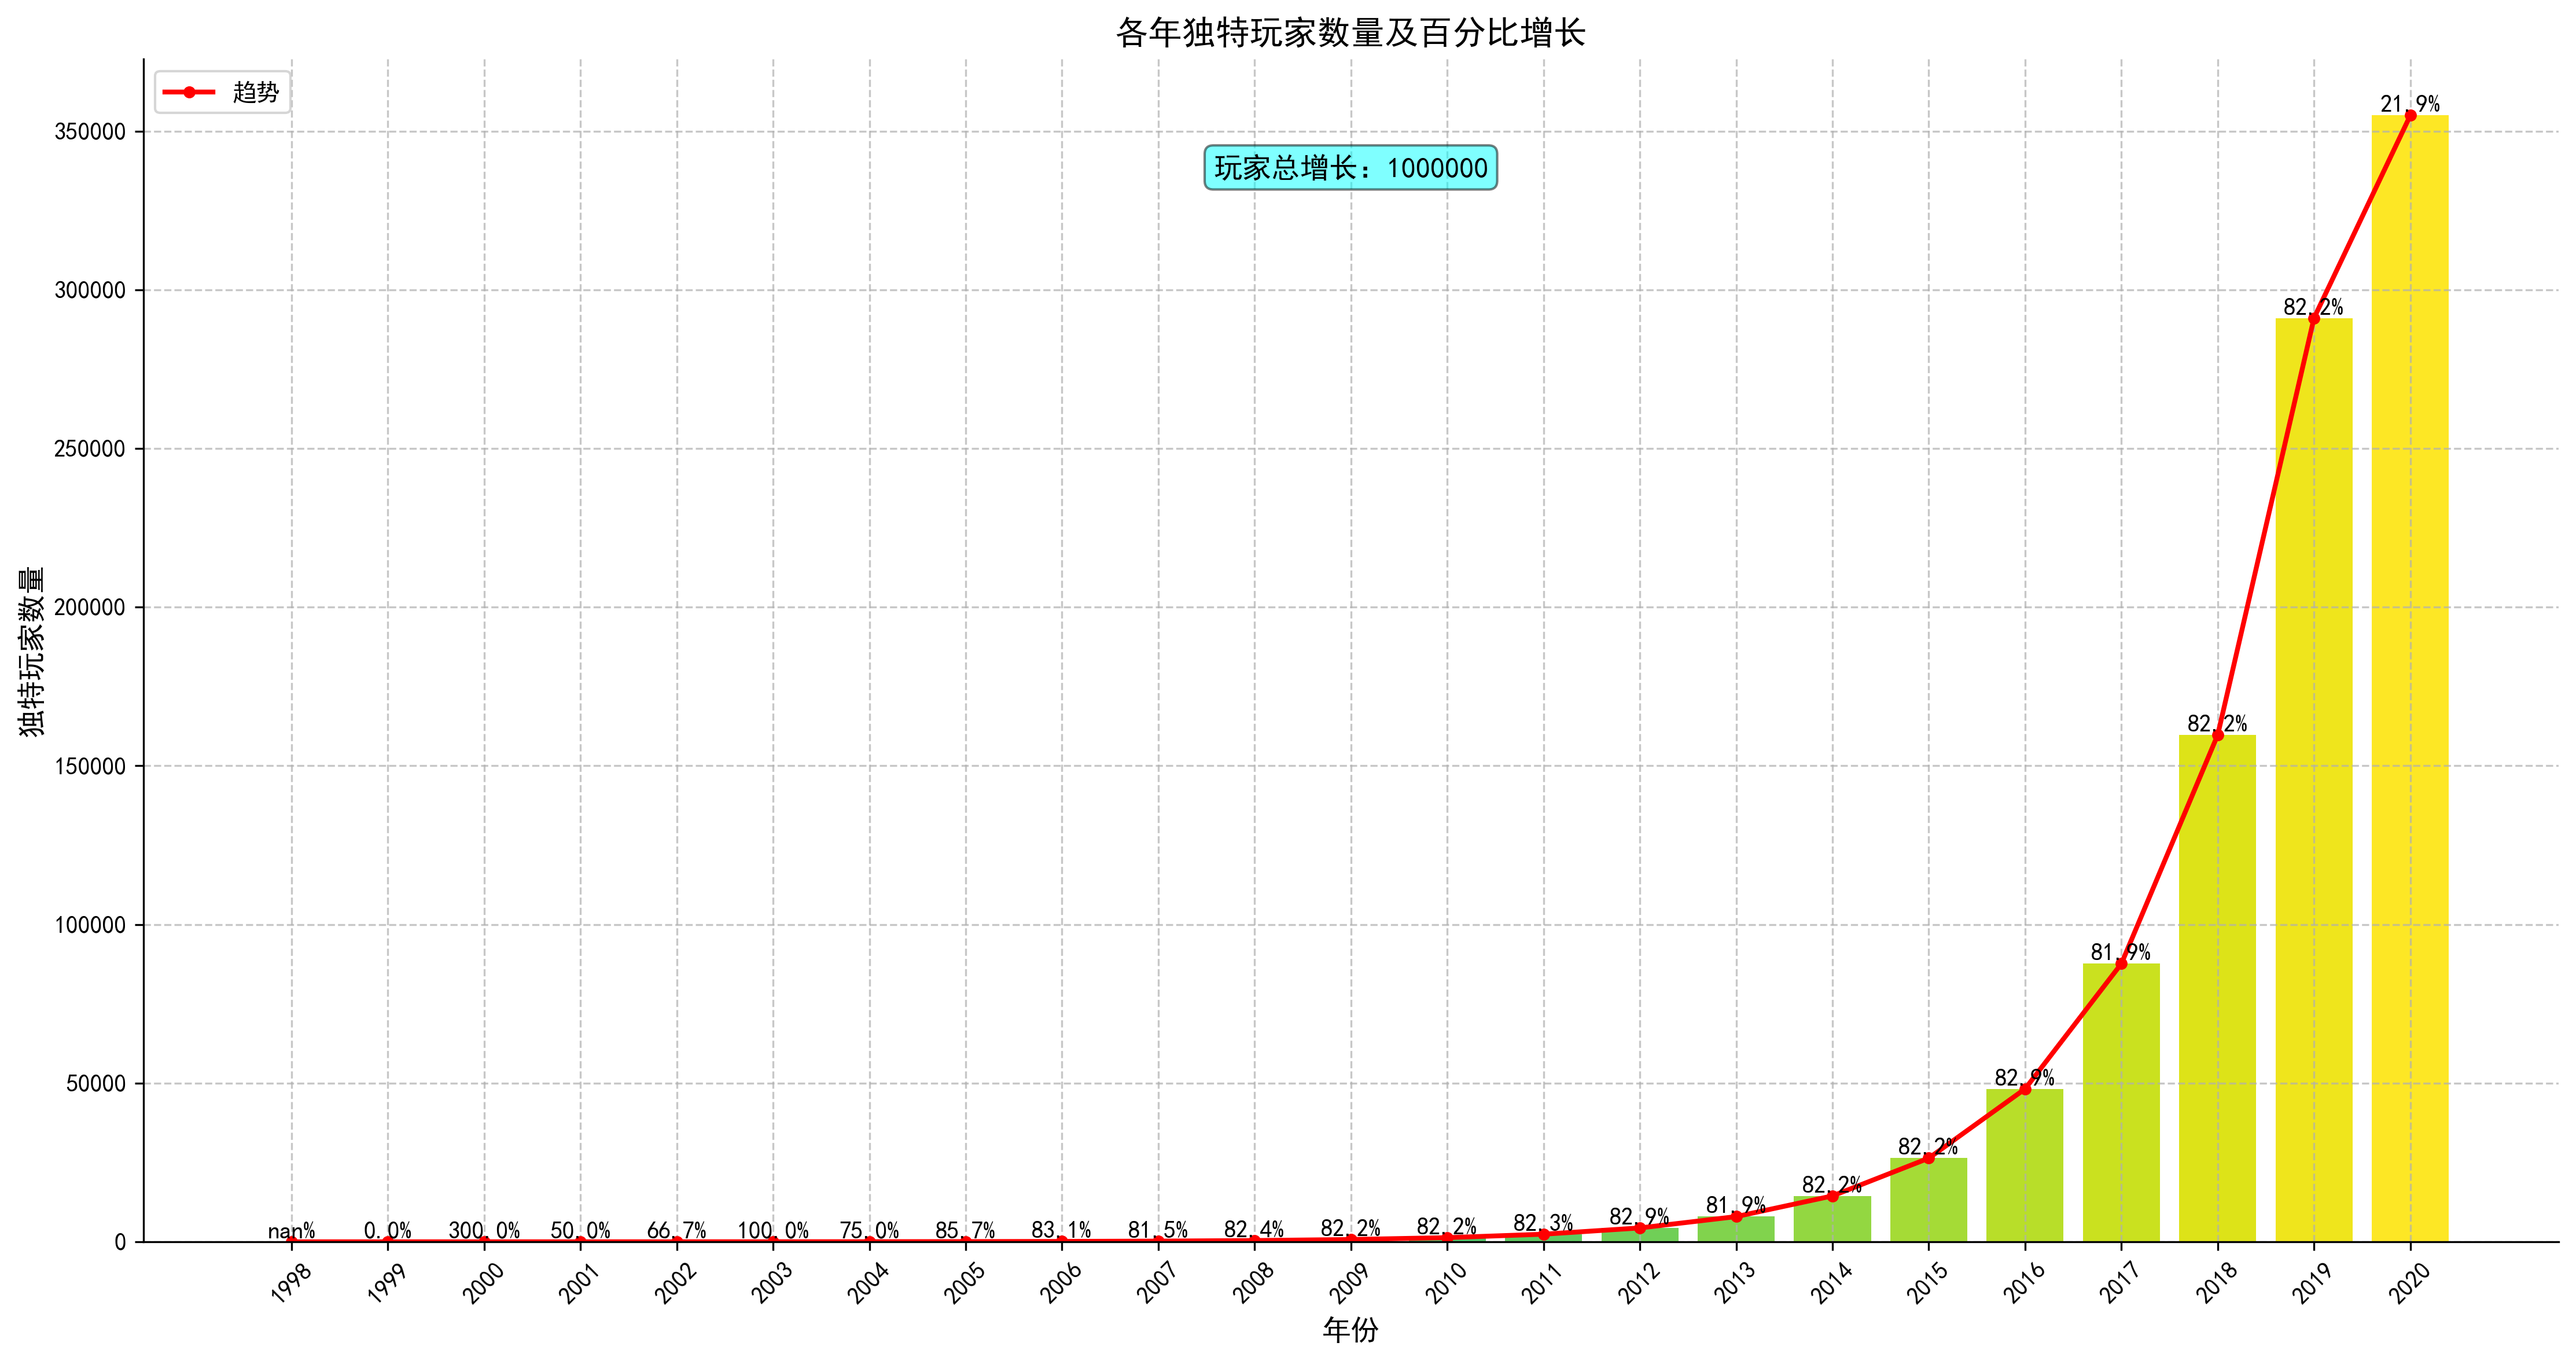

In [24]:
# 添加注册年份列
reg_data['reg_year'] = reg_data['date'].dt.year

# 筛选1998年及以后的数据
reg_data_1998 = reg_data[reg_data['date'] >= '1998-01-01']

# 按年份计算唯一用户数量
yearly_growth = reg_data_1998.groupby('reg_year')['uid'].nunique()

# 计算与上一年相比新玩家的百分比增长
growth_percentages = yearly_growth.pct_change() * 100

# 创建从浅到深的渐变色彩映射
##colors = plt.cm.Blues_r(np.linspace(0.2, 1, len(yearly_growth)))
colors = plt.cm.viridis(np.linspace(0.4, 1, len(yearly_growth)))


# 绘制带注释和趋势线的柱状图
plt.figure(figsize=(15, 8))
bars = plt.bar(yearly_growth.index.astype(str), yearly_growth.values, color=colors)
plt.plot(yearly_growth.index.astype(str), yearly_growth.values, marker='o', color='red', linestyle='-', linewidth=2, label='趋势')
plt.title('各年独特玩家数量及百分比增长')
plt.xlabel('年份')
plt.ylabel('独特玩家数量')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(loc='upper left')

# 添加与上一年相比新玩家百分比增长的注释
for i, bar in enumerate(bars):
    growth_percentage = growth_percentages.iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{growth_percentage:.1f}%', 
             ha='center', va='bottom', fontsize=10, color='black')

# 添加总增长文本注释
total_growth = (yearly_growth.iloc[-1] - yearly_growth.iloc[0]) / yearly_growth.iloc[0] * 100
plt.annotate(f'玩家总增长：{len(reg_data.uid.unique())}', xy=(0.5, 0.9), xycoords='axes fraction',
             fontsize=12, ha='center', bbox=dict(boxstyle='round,pad=0.3', fc='cyan', alpha=0.5))

plt.tight_layout()
plt.show()

### 图表结论

图表显示了各年独特玩家数量及百分比增长。

**主要观察：**
1. **玩家数量急剧增长：**
   - 从2016年开始，独特玩家数量呈爆发式增长。
   - 2018年玩家增长率为82.2%，到2020年达到21.9%。

2. **稳定增长：**
   - 从1998年到2015年，玩家增长不太显著，偶有小幅波动。这表明项目处于缓慢增长或稳定阶段。

3. **指数增长：**
   - 从2016年开始可以看到指数级增长，一直持续到2020年。这表明成功的营销策略或游戏流行度导致玩家基数大幅增加。

4. **玩家总增长：**
   - 整个期间独特玩家的总增长为1,000,000。

**结论：**
图表展示了项目的成功发展，特别是在最近几年，独特玩家数量急剧增加。这可能表明产品改进或营销活动取得了显著成效，从而提高了用户兴趣和参与度。

### 留存率

C:\Users\za01\AppData\Local\Temp\ipykernel_460736\1707431465.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  retention_data = pd.concat([retention_data, new_row], ignore_index=True)
C:\Users\za01\AppData\Local\Temp\ipykernel_460736\1707431465.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  retention_data = pd.concat([retention_data, new_row], ignore_index=True)


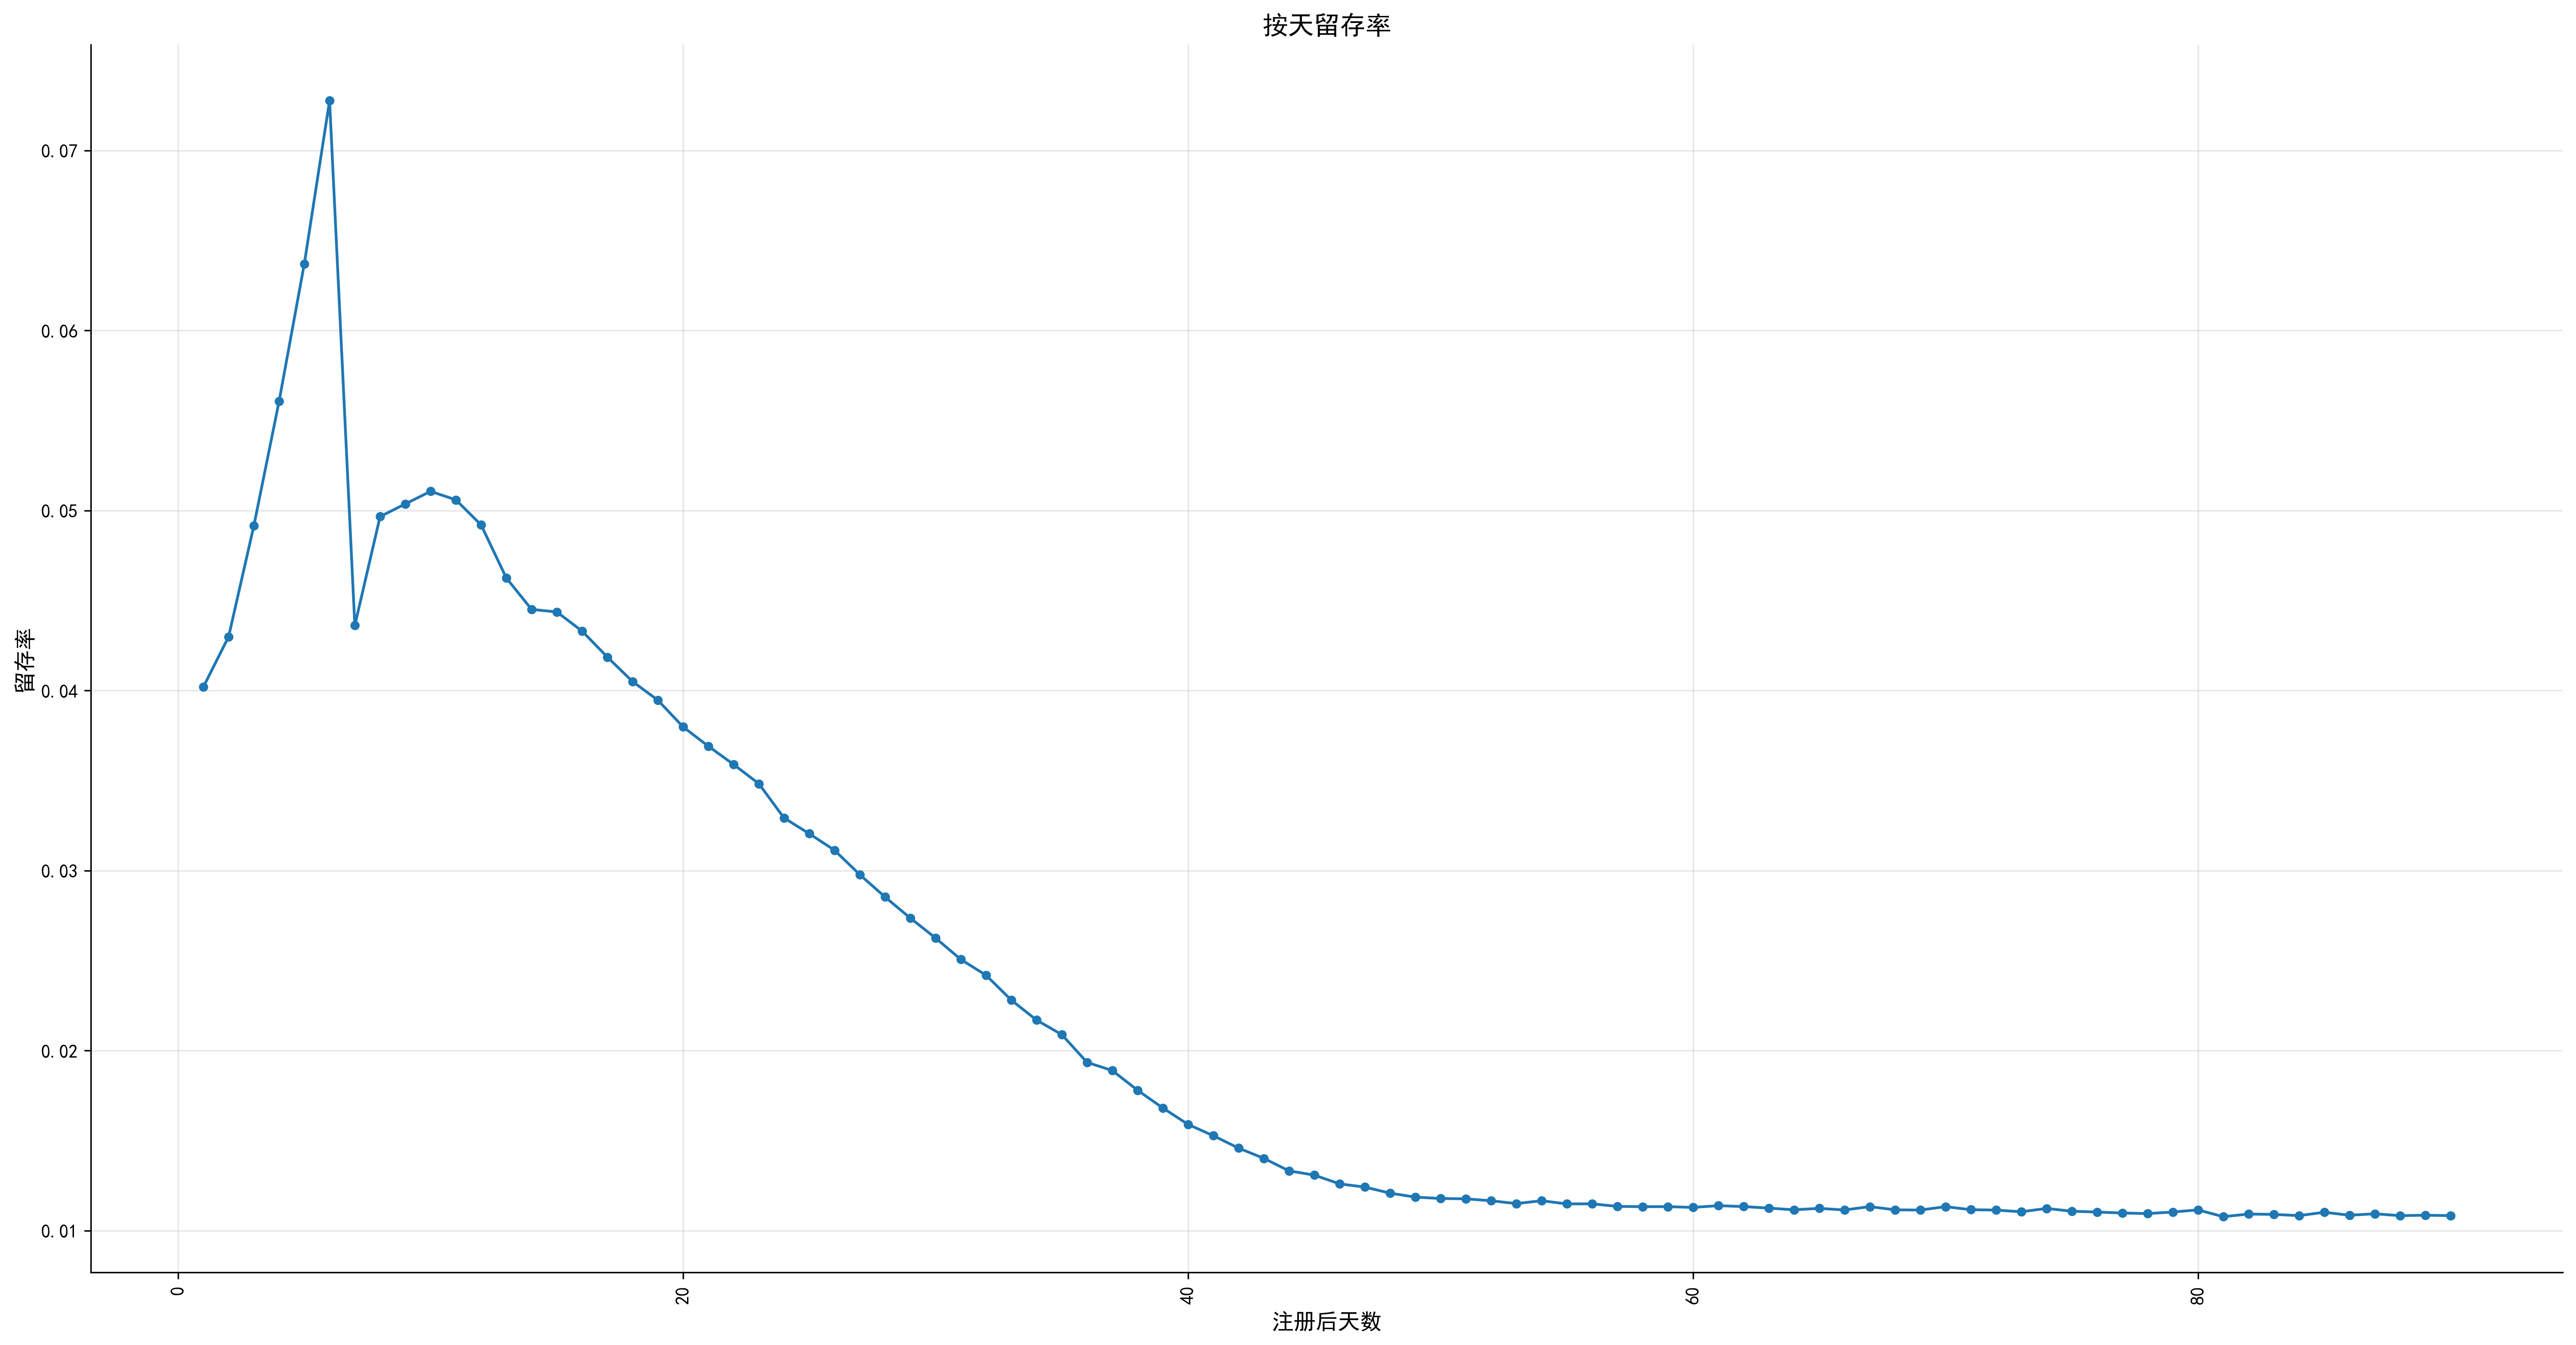

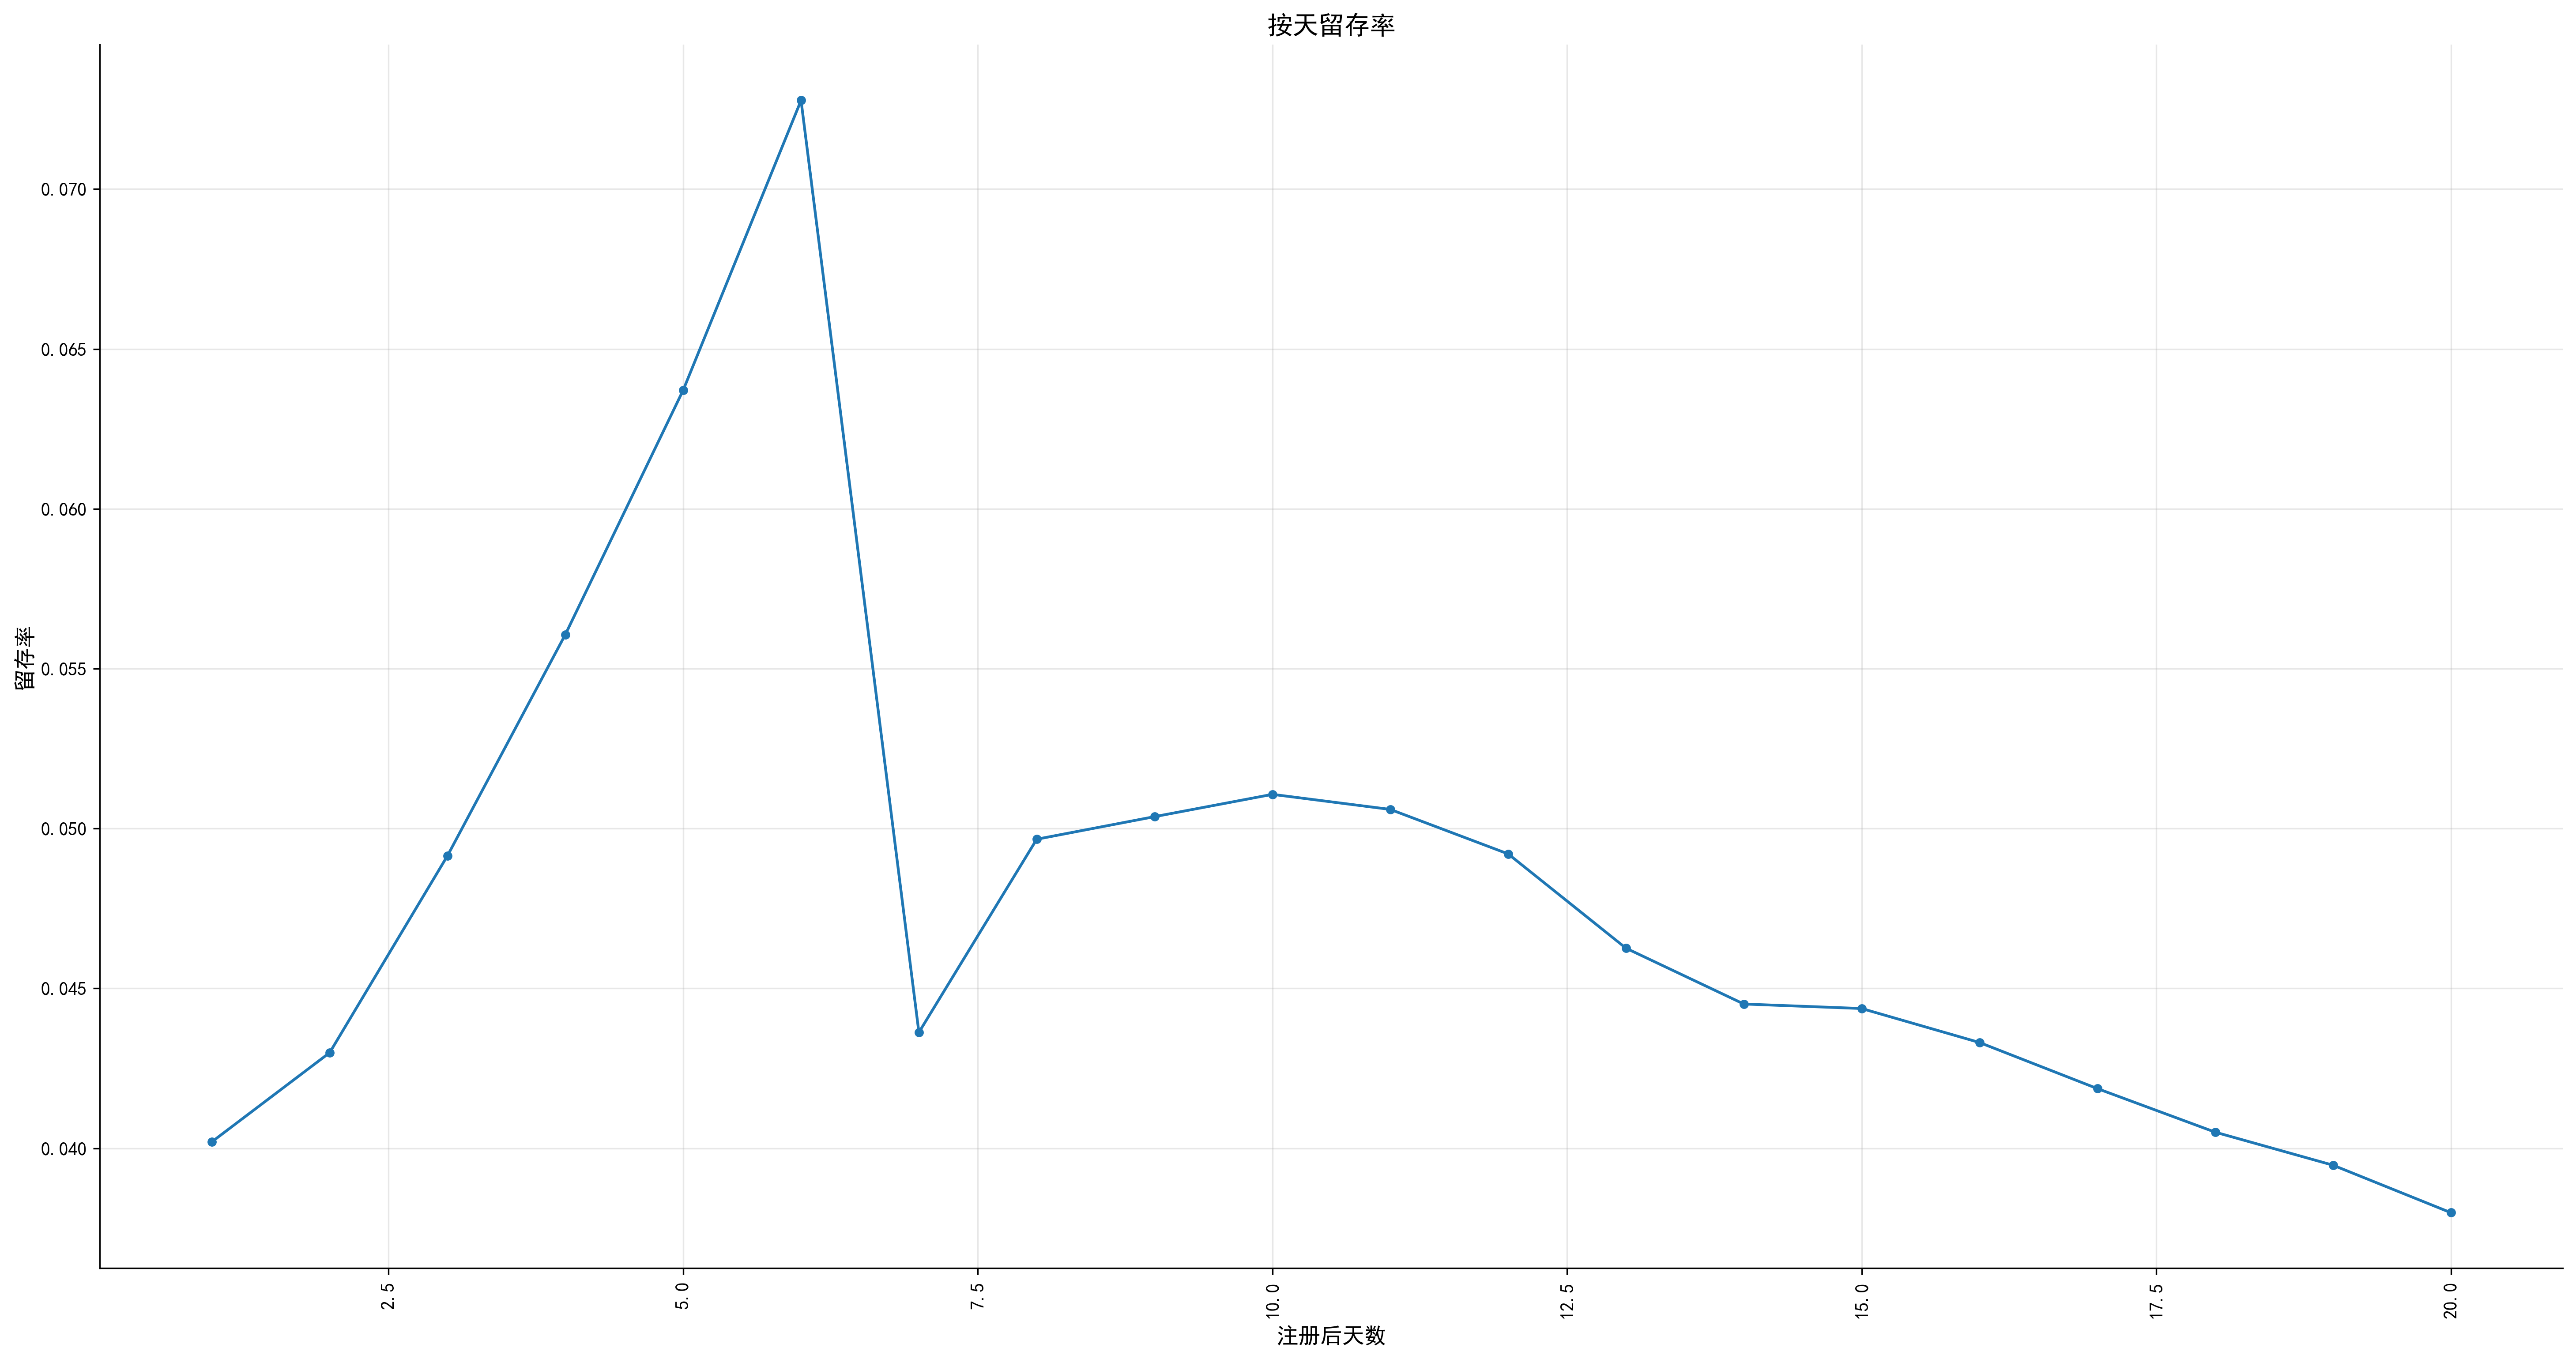

In [25]:
"""
用户留存分析和数据可视化：
1. 按月计算留存率并以热力图形式可视化。
2. 按天计算留存率并绘制图表。
"""

# 创建原始数据的副本
reg_data_copy = reg_data.copy()
auth_data_copy = auth_data.copy()

# 为每个用户确定注册月份
reg_data_copy['reg_month'] = reg_data_copy['date'].dt.to_period('M')

# 将用户登录游戏的时间数据与注册数据合并
data = pd.merge(auth_data_copy, reg_data_copy[['uid', 'reg_month']], on='uid', how='left')

# 确定用户登录游戏的月份
data['active_month'] = data['date'].dt.to_period('M')

# 按注册月份创建群组
cohorts = data.groupby(['reg_month', 'active_month']).agg({'uid': 'nunique'}).reset_index()

# 为每个群组确定第一个月份
cohorts['period_number'] = (cohorts['active_month'] - cohorts['reg_month']).apply(lambda x: x.n)

# 创建用于热力图的透视表
cohort_pivot = cohorts.pivot_table(index='reg_month', columns='period_number', values='uid')

# 将每个值除以群组中用户的数量以获得百分比
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 筛选2015年至2020年期间的数据
start_date = '2015-01'
end_date = '2020-12'
filtered_reg_data = reg_data_copy[(reg_data_copy['reg_month'] >= start_date) & (reg_data_copy['reg_month'] <= end_date)]

# 重新计算群组和透视表
filtered_data = pd.merge(auth_data_copy, filtered_reg_data[['uid', 'reg_month']], on='uid', how='left')
filtered_data['active_month'] = filtered_data['date'].dt.to_period('M')
cohorts = filtered_data.groupby(['reg_month', 'active_month']).agg({'uid': 'nunique'}).reset_index()
cohorts['period_number'] = (cohorts['active_month'] - cohorts['reg_month']).apply(lambda x: x.n)
cohort_pivot = cohorts.pivot_table(index='reg_month', columns='period_number', values='uid')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 可视化
plt.figure(figsize=(40, 25))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='Blues', cbar_kws={'format': '%.0f%%'})
plt.title('月度留存率')
plt.xlabel('群组周期')
plt.ylabel('群组月份')
plt.show()

# 重新计算群组和透视表
final_data = pd.merge(auth_data_copy, filtered_reg_data[['uid', 'reg_month']], on='uid', how='left')
final_data['active_month'] = final_data['date'].dt.to_period('M')
cohorts = final_data.groupby(['reg_month', 'active_month']).agg({'uid': 'nunique'}).reset_index()
cohorts['period_number'] = (cohorts['active_month'] - cohorts['reg_month']).apply(lambda x: x.n)
cohort_pivot = cohorts.pivot_table(index='reg_month', columns='period_number', values='uid')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 可视化
plt.figure(figsize=(70, 25))
sns.heatmap(cohort_pivot, annot=True, fmt='', cmap='Blues')
plt.title('月度留存率')
plt.xlabel('群组周期')
plt.ylabel('群组月份')
plt.show()

# 创建数据副本
reg_data_copy = reg_data.copy()
auth_data_copy = auth_data.copy()

# 将字符串转换为datetime
reg_data_copy['datetime'] = pd.to_datetime(reg_data_copy['date'].astype(str) + ' ' + reg_data_copy['time'])
auth_data_copy['datetime'] = pd.to_datetime(auth_data_copy['date'].astype(str) + ' ' + auth_data_copy['time'])

# 删除不需要的列
reg_data_copy = reg_data_copy.drop(['date', 'time'], axis=1)
auth_data_copy = auth_data_copy.drop(['date', 'time'], axis=1)

def calculate_retention(reg_data, auth_data, days):
    """
    按天计算用户留存率。

    参数：
    reg_data (DataFrame)：用户注册数据。
    auth_data (DataFrame)：用户登录游戏的时间数据。
    days (int)：计算留存率的天数。

    返回：
    DataFrame：用户留存数据。
    """
    # 合并注册和认证数据
    merged_data = pd.merge(auth_data, reg_data, on='uid', suffixes=('_auth', '_reg'))
    
    # 计算认证和注册之间的天数差
    merged_data['days_diff'] = (merged_data['datetime_auth'] - merged_data['datetime_reg']).dt.days
    
    # 创建空DataFrame用于存储结果
    retention_data = pd.DataFrame(columns=['day', 'retention'])
    
    for day in range(1, days + 1):
        # 计算在特定天数后返回游戏的用户数量
        retained_users = merged_data[merged_data['days_diff'] == day]['uid'].nunique()
        # 计算注册用户总数
        total_users = reg_data['uid'].nunique()
        # 计算留存率
        retention = retained_users / total_users
        # 将结果添加到DataFrame
        new_row = pd.DataFrame({'day': [day], 'retention': [retention]})
        retention_data = pd.concat([retention_data, new_row], ignore_index=True)
    
    return retention_data

def plot_retention(retention_data):
    """
    绘制用户留存率图表。

    参数：
    retention_data (DataFrame)：用户留存数据。

    返回：
    None
    """
    plt.figure(figsize=(24, 12))
    plt.plot(retention_data['day'], retention_data['retention'], marker='o')
    plt.title('按天留存率')
    plt.xlabel('注册后天数')
    plt.ylabel('留存率')
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.show()

# 使用示例
retention_data = calculate_retention(reg_data_copy, auth_data_copy, 90)
retention_data2 = calculate_retention(reg_data_copy, auth_data_copy, 20)

plot_retention(retention_data)
plot_retention(retention_data2)

### 🎃 留存率数据结果

#### 数据可视化
从提供的图表中可以观察到：

1. **群组留存分析**：
   - 图表是一个表格，纵轴表示用户注册月份，横轴表示自注册以来经过的月份。
   - 表格中的值表示每个群组在注册后特定月份的留存百分比。

2. **按天留存率图表**：
   - 折线图展示了特定时期内用户返回的百分比。

#### 数据分析
- **初始留存**：
  - 注册后第一个月，留存率在7%到9%之间变化。
  - 注册后的前几天（1-5天）可以观察到较高的用户返回百分比。

- **留存率下降**：
  - 第一个月后，所有群组的留存率都出现下降。
  - 第一个峰值后留存率急剧下降，这是大多数产品的典型情况。

- **季节性波动和稳定**：
  - 从4-5个月开始，留存率稳定在4-5%的水平，表明存在一个小但忠诚的用户群体。
  - 从第12个月开始，留存率逐渐降至2-3%。
  - 图表中可以注意到后期（10天后）用户返回率的波动，这可能与各种外部因素有关。
  - 从第20天开始，留存率稳定在较低水平。

#### 结论
1. **初始兴趣**：
   - 第一个月和注册后前几天的高留存率表明用户在注册后立即对产品感兴趣。这是一个积极的信号。

2. **留存问题**：
   - 第一个月和前几天后留存率显著下降表明存在用户留存问题。这可能与用户体验不佳、功能不足或与其他产品的竞争有关。

3. **活跃用户核心**：
   - 4-5个月和20天后低但稳定的留存率水平表明存在一小群用户，他们发现产品有价值并长期继续使用。

## 🍂 任务2

### A/B测试

有A/B测试的结果，其中两组用户被提供了不同的促销方案。已知测试组的ARPU比对照组高5%。同时，对照组中202,103名玩家中有1,928名付费，测试组中202,667名玩家中有1,805名付费。

- 应该分析哪些指标以做出正确的决策？如何分析？
- 哪套促销方案可以认为是最佳的？

#### 1) 应该分析哪些指标以做出正确的决策？如何分析？

为了做出正确的决策，应该分析以下指标：

- **ARPU（每用户平均收入）：** 两组中每个用户的平均收入。
- **CR（转化率）：** 进行购买的用户百分比。
- **ARPPU（每付费用户平均收入）：** 每个付费用户的平均收入。

**ARPU**

每用户平均收入是一个指标，帮助理解一个用户在特定时期内平均带来多少收入。ARPU有助于理解每个用户的收入。

**转化率**

转化率是执行目标操作（例如购买）的用户占用户总数的百分比。CR显示了执行目标操作的用户百分比。

**ARPPU**

每付费用户平均收入（ARPPU）是一个指标，衡量每个付费用户在特定时期内产生的平均收入。它通过将来自所有付款的总收入除以该时期的付费用户数量来计算。ARPPU允许评估每个付费客户对公司总收入的贡献。

#### 2) 哪套促销方案可以认为是最佳的？

在以下情况下，测试组的促销方案可以认为是最佳的：

1. **ARPU（每用户平均收入）：**
   - 测试组ARPU增加5%具有统计显著性。

2. **CR（转化率）：**
   - 测试组中付费用户的百分比较高，且与对照组相比具有统计显著性。

3. **ARPPU（每付费用户平均收入）：**
   - 测试组中每付费用户的平均收入较高，且具有统计显著性。

#### 假设：

- **H₀**：不同促销方案在ARPU、CR和ARPPU指标上没有统计显著差异。
- **H₁**：其中一套促销方案在一个或多个关键指标（ARPU、CR和ARPPU）上显示出统计显著的改进。

### A/B测试的问题：

1. **泛化问题：**
    - 如果数据是在短时间内或在特殊条件下（例如促销期间）收集的，则数据可能不具代表性。没有关于数据收集期间以及用户如何被分配到对照组和测试组的信息。

2. **缺乏详细信息：**
    - 只有关于付费玩家数量和ARPU的聚合数据。没有关于购买分布、购买频率以及测试前后玩家行为的信息。

3. **潜在的样本偏差：**
    - 测试的玩家样本可能不是随机的。例如，某些玩家可能由于特定特征而更频繁地进入测试组，这可能扭曲结果。

4. **外部因素的影响：**
    - 外部因素，如营销活动变化、竞争和季节性波动，可能影响玩家行为并扭曲测试结果。

5. **未考虑的因素：**
    - 许多因素，如玩家之前的经验和测试进行的时间，可能影响结果但未被考虑。

### 运行ARPU、CR、ARPPU

In [26]:
# ARPU
arpu_control = ab_test[ab_test['testgroup'] == 'a']['revenue'].mean()
arpu_test = ab_test[ab_test['testgroup'] == 'b']['revenue'].mean()

# CR
cr_control = ab_test[ab_test['testgroup'] == 'a']['revenue'].apply(lambda x: x > 0).mean()
cr_test = ab_test[ab_test['testgroup'] == 'b']['revenue'].apply(lambda x: x > 0).mean()

# ARPPU
arppu_control = ab_test[(ab_test['testgroup'] == 'a') & (ab_test['revenue'] > 0)]['revenue'].mean()
arppu_test = ab_test[(ab_test['testgroup'] == 'b') & (ab_test['revenue'] > 0)]['revenue'].mean()

# 输出
print(f"ARPU（对照组）：{arpu_control}")
print(f"ARPU（测试组）：{arpu_test}")
print(f"转化率（对照组）：{cr_control}")
print(f"转化率（测试组）：{cr_test}")
print(f"ARPPU（对照组）：{arppu_control}")
print(f"ARPPU（测试组）：{arppu_test}")

ARPU（对照组）：25.413719736965806
ARPU（测试组）：26.75128659327863
转化率（对照组）：0.009539690157988749
转化率（测试组）：0.008906235351586593
ARPPU（对照组）：2663.9984439834025
ARPPU（测试组）：3003.6581717451522


### 指标结论

- **ARPU：** 测试组（26.75）略高于对照组（25.41）。
- **转化率：** 对照组（0.95%）高于测试组（0.89%）。
- **ARPPU：** 测试组（3003.66）高于对照组（2664.00）。

测试组在ARPU和ARPPU上表现更好，但差异不具有统计显著性，这支持了零假设。

## 指标分析：ARPU、CR、ARPPU

- #### 达戈斯蒂诺-皮尔逊检验：用于检查数据的正态性。

选择达戈斯蒂诺-皮尔逊检验的原因：

1. **适用于大样本**：对照组（202,103）和测试组（202,667）的样本量很大，该检验能有效验证ARPU分布的正态性。

2. **综合分析**：该检验同时评估偏度和峰度，这对于评估ARPU（对照组：25.41，测试组：26.75）偏离正态分布的程度很重要。

3. **对统计数据的可靠性**：达戈斯蒂诺-皮尔逊检验适用于有小偏差的数据，确保结果准确。

- #### Q-Q图：用于可视化检验正态性。

Q-Q图可以直观评估数据与正态分布的符合程度，补充统计检验的结果。

- #### 莱文检验：用于检验方差齐性。

选择莱文检验的原因：

1. **适用于大样本**：莱文检验适用于分析对照组（202,103）和测试组（202,667）的方差齐性。

2. **评估方差均匀性**：莱文检验有助于确定ARPU（对照组：25.41，测试组：26.75）的方差差异是否具有统计显著性。

3. **独立于正态性**：莱文检验不依赖于数据的正态分布，这使其在正态性未确认的情况下很有用。

- #### 置信区间：用于ARPU。

置信区间确定了ARPU真实均值所在的范围，这对于评估结果的显著性和可靠性很重要。

对照组达戈斯蒂诺和皮尔逊检验： NormaltestResult(statistic=np.float64(585152.7312728433), pvalue=np.float64(0.0))
测试组达戈斯蒂诺和皮尔逊检验： NormaltestResult(statistic=np.float64(326622.39540856465), pvalue=np.float64(0.0))


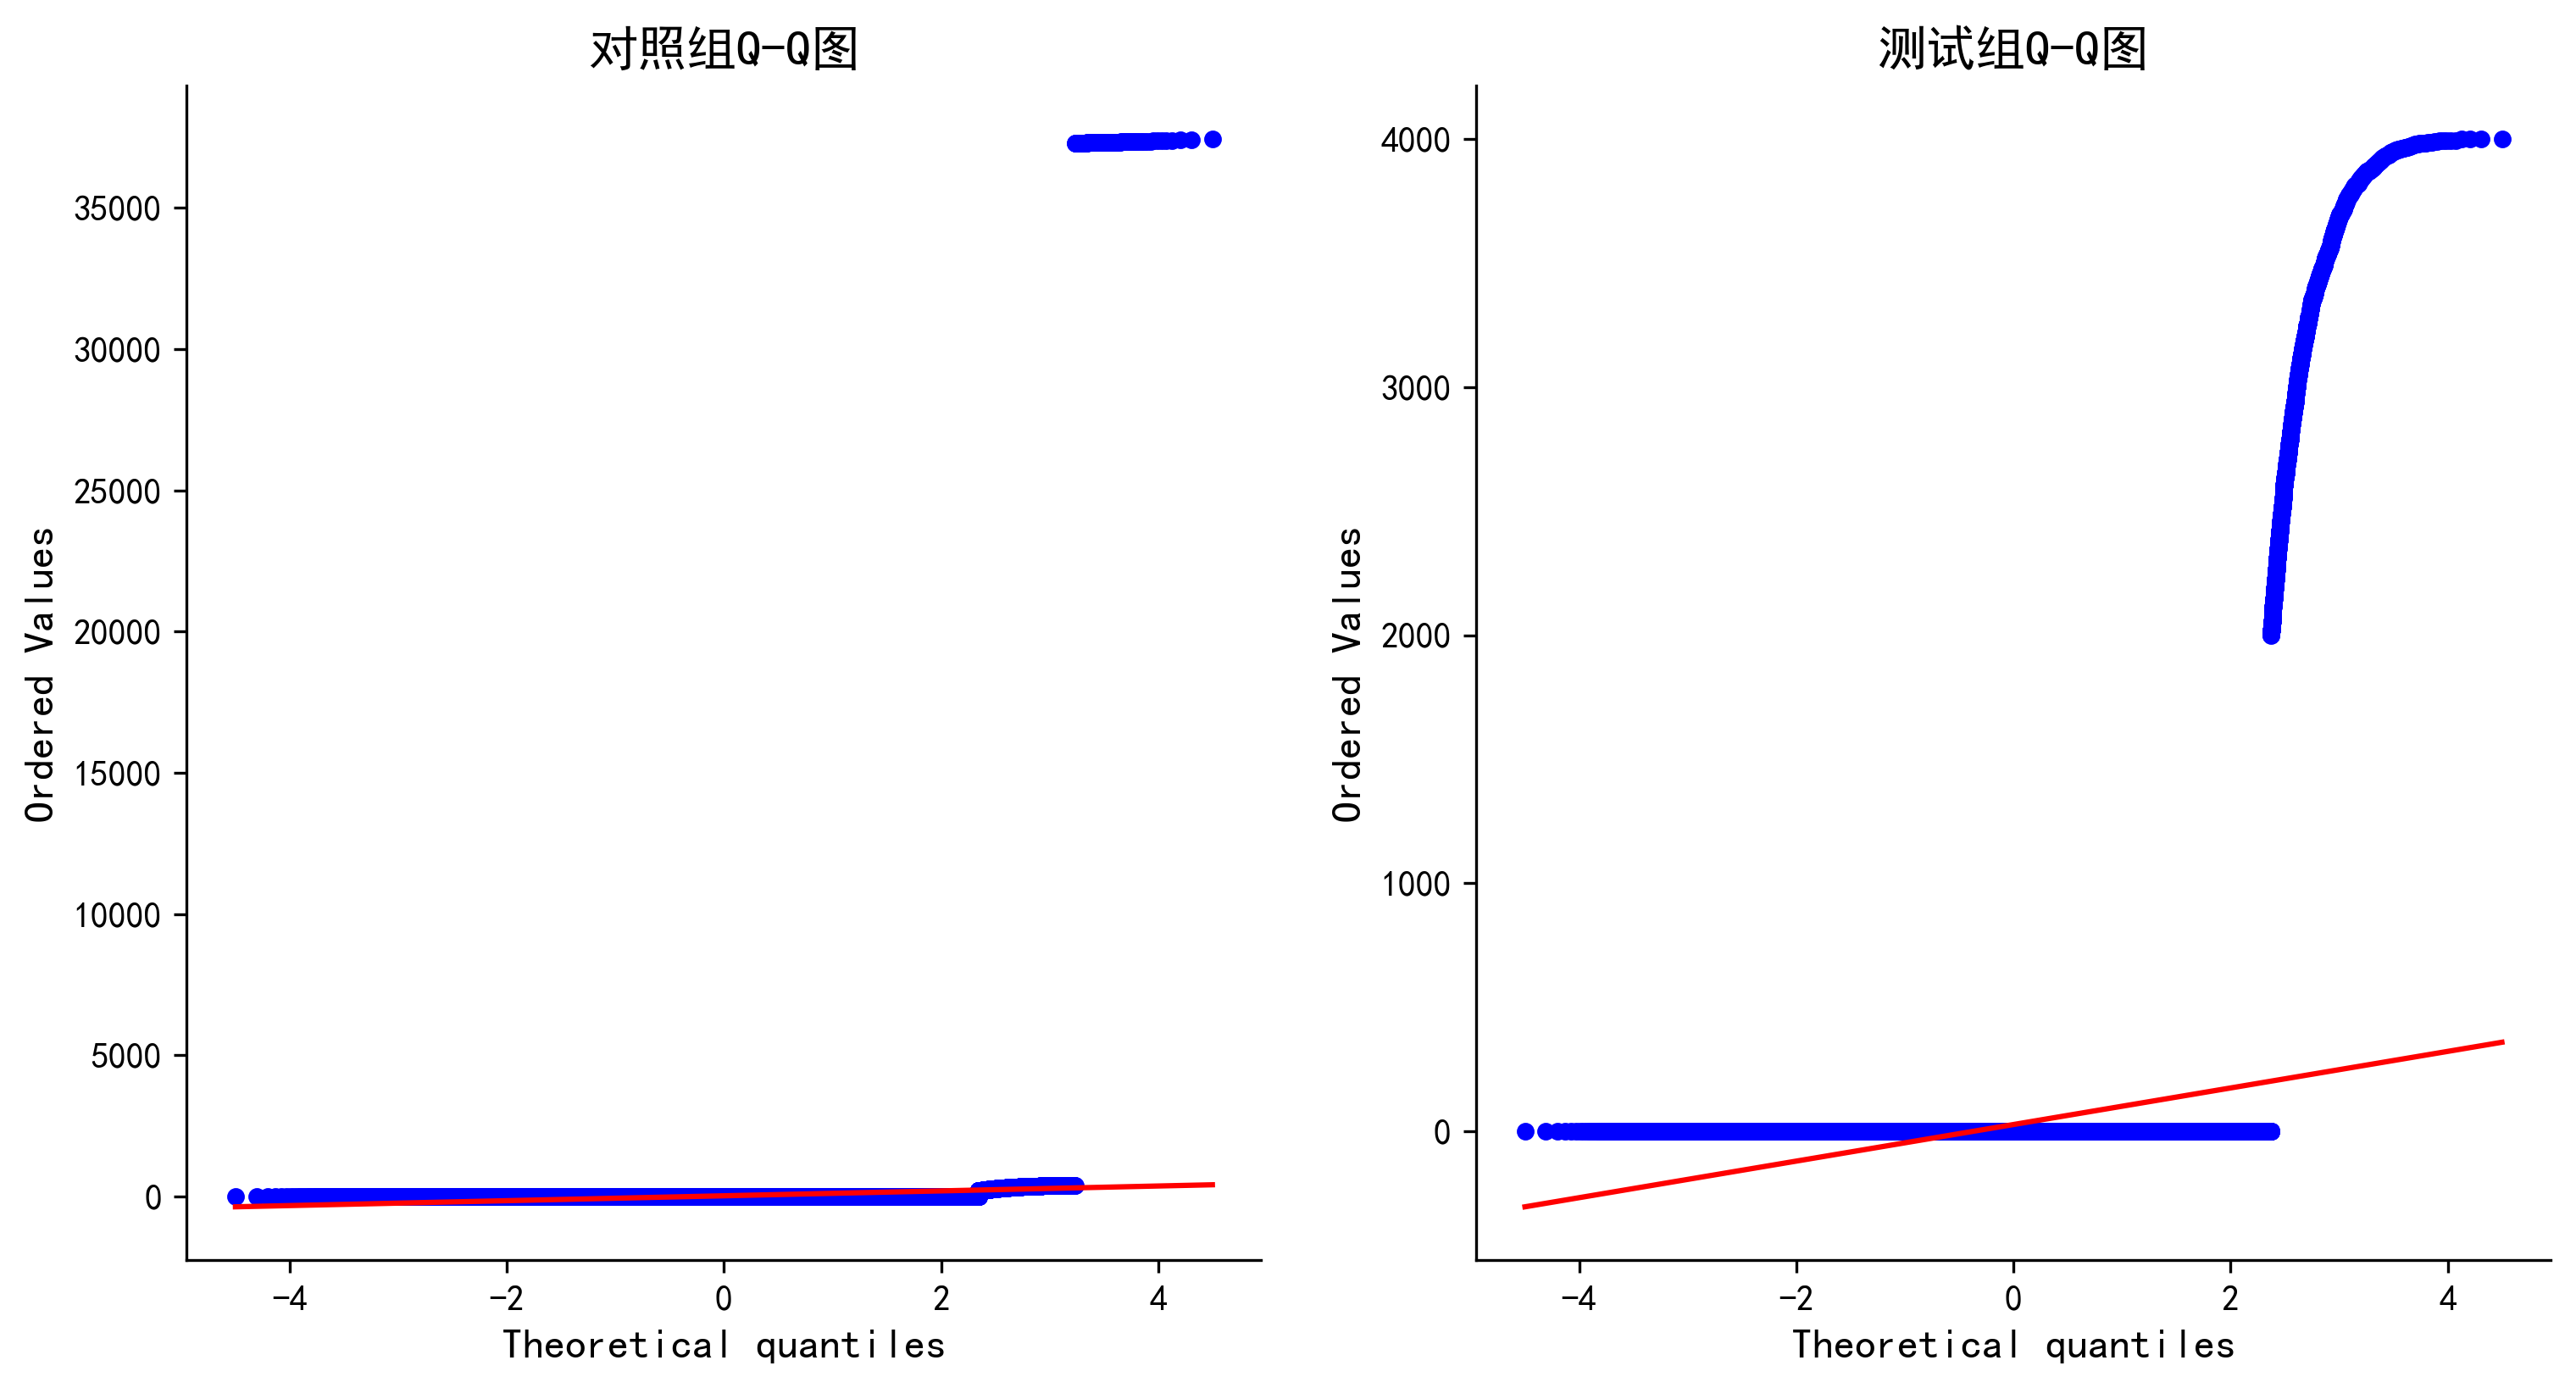

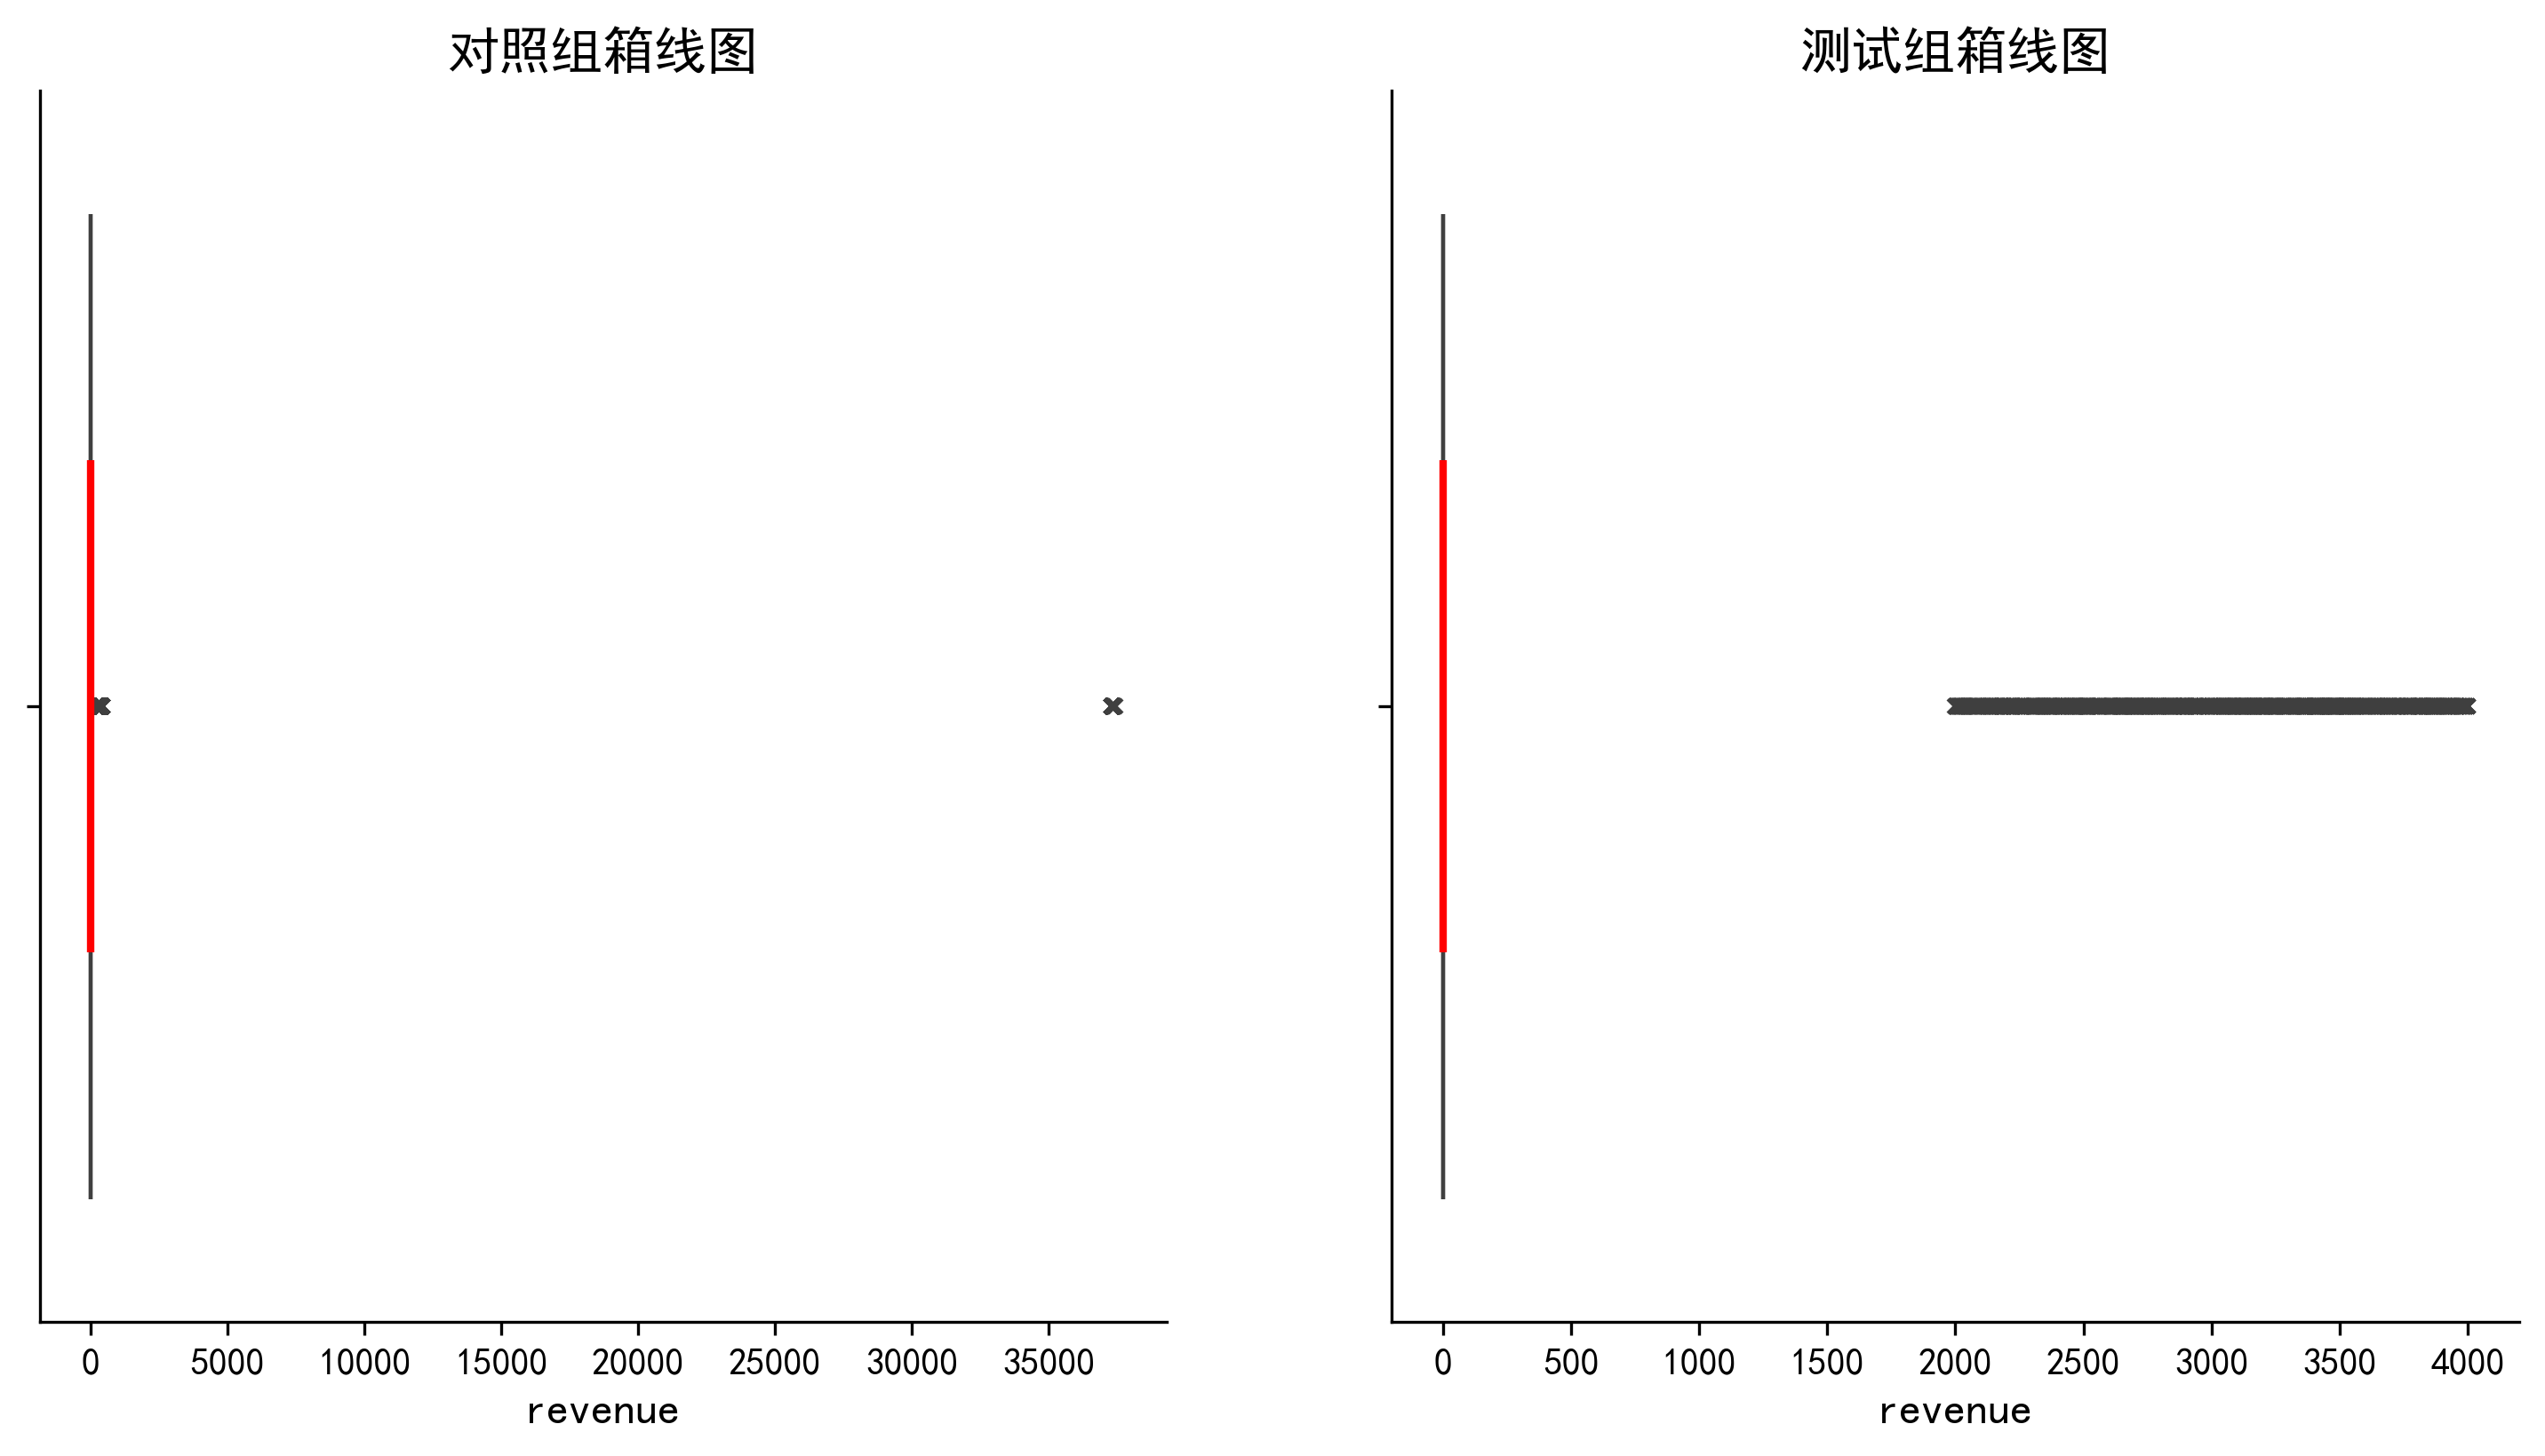

对照组异常值： 72          351
341         290
385         250
416       37324
712         255
          ...  
404304      360
404315      262
404543      369
404602      251
404767      231
Name: revenue, Length: 1928, dtype: int64
测试组异常值： 160       3797
377       3768
386       3527
551       2038
913       3902
          ... 
403843    3383
403994    2793
404161    2316
404193    2998
404525    3120
Name: revenue, Length: 1805, dtype: int64
莱文检验：统计量 = 0.3896289474701388 ，p值 = 0.5324948591043842
对照组95%置信区间： (np.float64(21.399375659496645), np.float64(29.428063814434967))
测试组95%置信区间： (np.float64(25.50036147387202), np.float64(28.002211712685238))


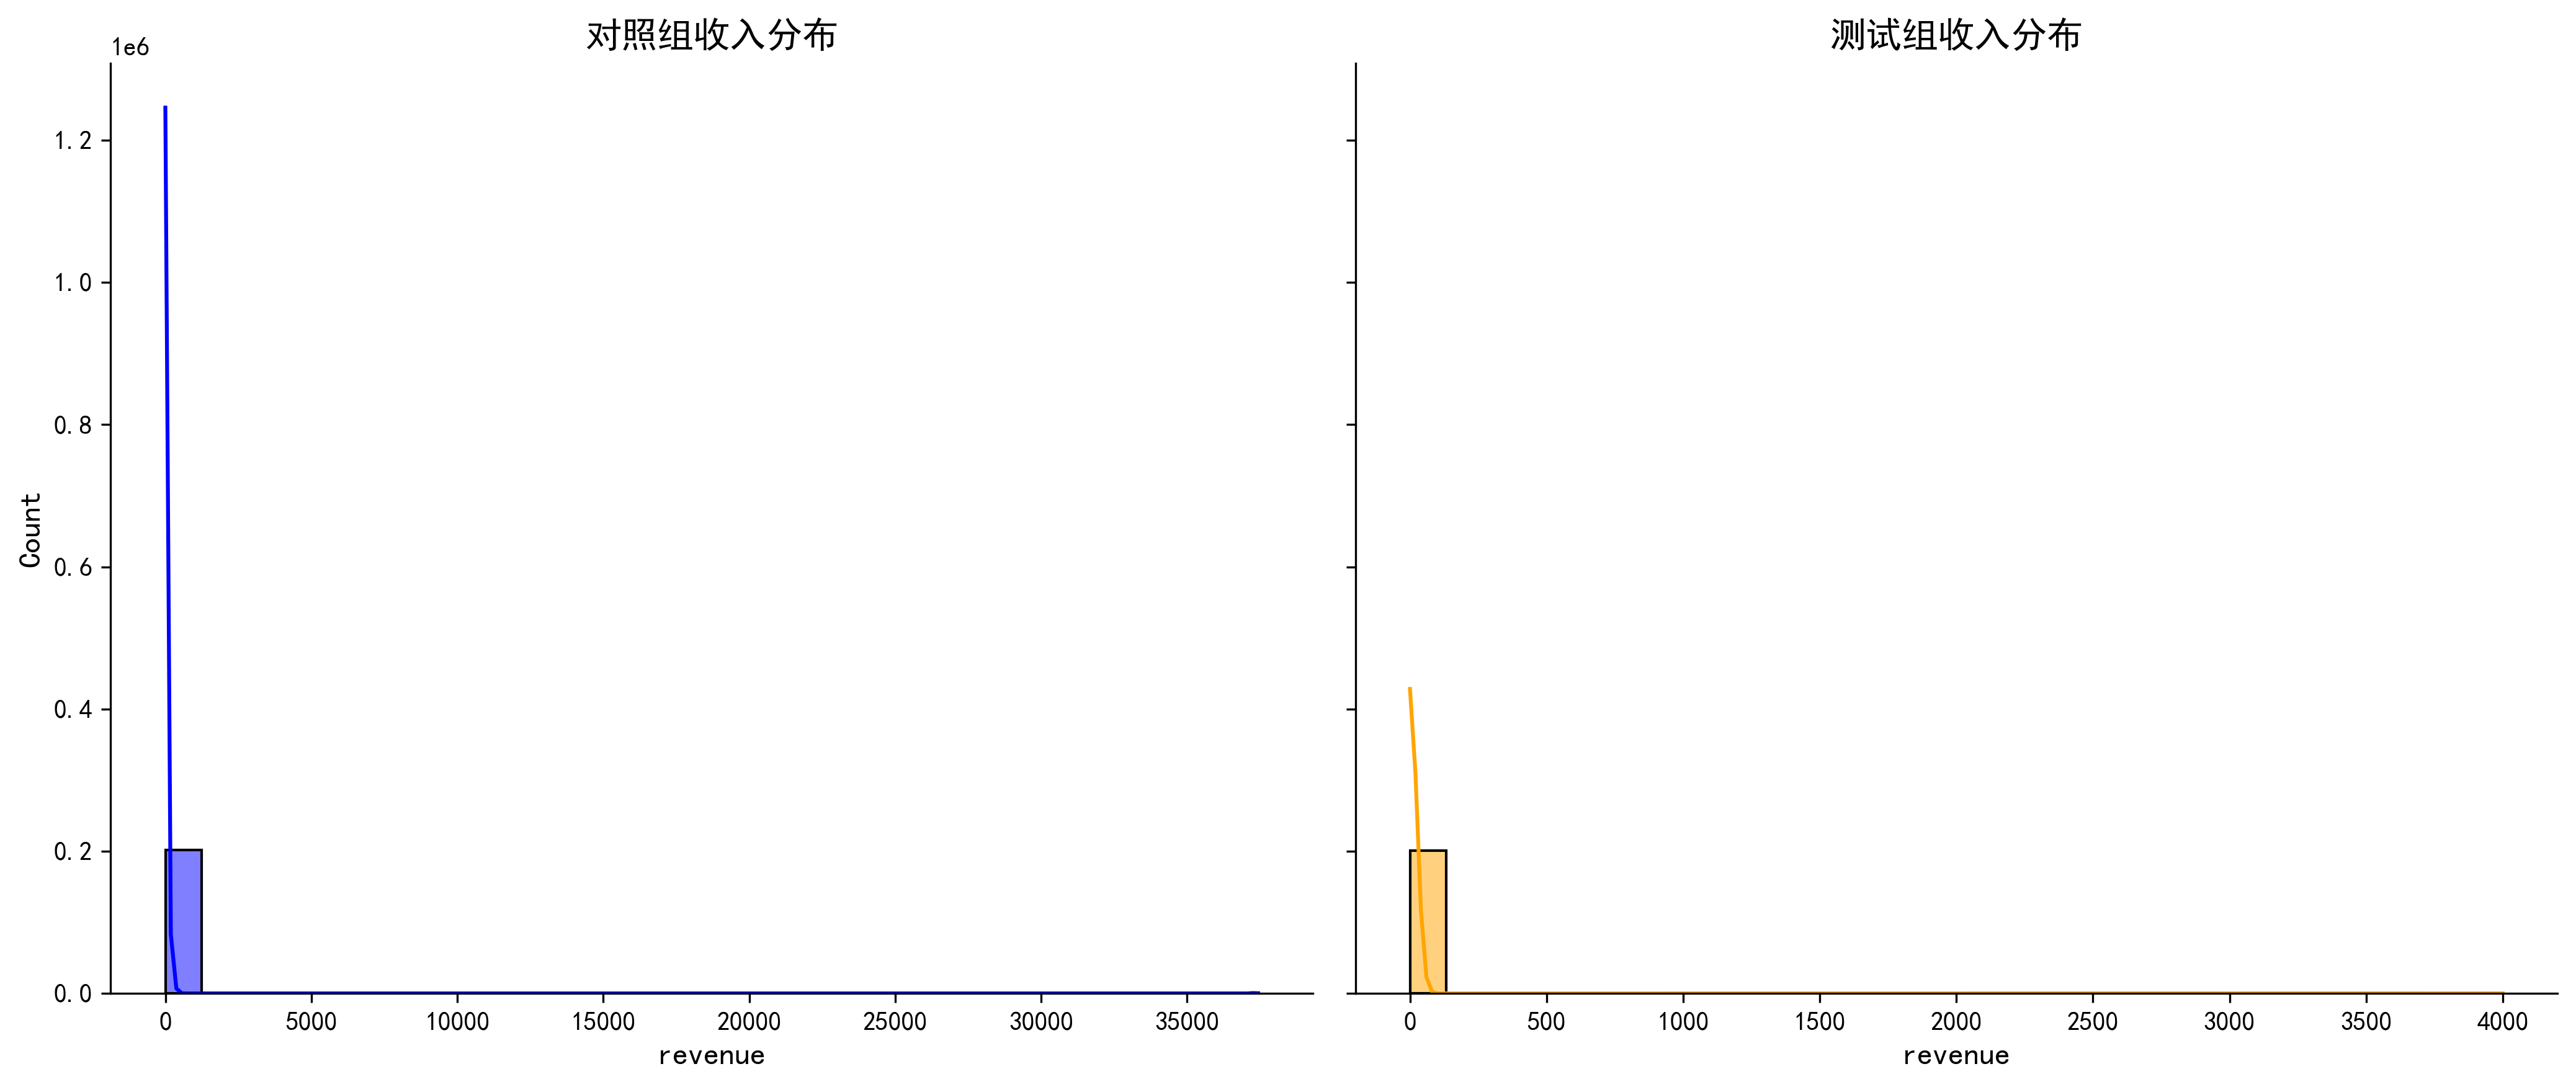

In [27]:
# 将数据分为测试组和对照组
control_group = ab_test[ab_test['testgroup'] == 'a']
test_group = ab_test[ab_test['testgroup'] == 'b']

# 正态性检验
# 使用达戈斯蒂诺和皮尔逊检验
print("对照组达戈斯蒂诺和皮尔逊检验：", stats.normaltest(control_group['revenue']))
print("测试组达戈斯蒂诺和皮尔逊检验：", stats.normaltest(test_group['revenue']))

# Q-Q图用于可视化正态性检验
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
stats.probplot(control_group['revenue'], dist="norm", plot=plt)
plt.title('对照组Q-Q图')

plt.subplot(1, 2, 2)
stats.probplot(test_group['revenue'], dist="norm", plot=plt)
plt.title('测试组Q-Q图')
plt.show()

# 检测异常值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(
    x=control_group['revenue'], 
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .7, .9, .5)},
    medianprops={"color": "r", "linewidth": 2}
)
plt.title('对照组箱线图')

plt.subplot(1, 2, 2)
sns.boxplot(
    x=test_group['revenue'], 
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .7, .9, .5)},
    medianprops={"color": "r", "linewidth": 2}
)
plt.title('测试组箱线图')
plt.show()

# 使用四分位距法检测异常值
def detect_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

print("对照组异常值：", detect_outliers(control_group['revenue']))
print("测试组异常值：", detect_outliers(test_group['revenue']))

# 检验方差齐性（莱文检验）
levene_stat, levene_p = stats.levene(control_group['revenue'], test_group['revenue'])
print("莱文检验：统计量 =", levene_stat, "，p值 =", levene_p)

# 计算置信区间
control_mean = np.mean(control_group['revenue'])
test_mean = np.mean(test_group['revenue'])

control_std = np.std(control_group['revenue'], ddof=1)
test_std = np.std(test_group['revenue'], ddof=1)

confidence_interval_control = stats.t.interval(0.95, len(control_group)-1, loc=control_mean, scale=control_std / np.sqrt(len(control_group)))
confidence_interval_test = stats.t.interval(0.95, len(test_group)-1, loc=test_mean, scale=test_std / np.sqrt(len(test_group)))

print("对照组95%置信区间：", confidence_interval_control)
print("测试组95%置信区间：", confidence_interval_test)

# 改进的结果可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.histplot(control_group['revenue'], bins=30, kde=True, ax=axes[0], color='blue')
sns.histplot(test_group['revenue'], bins=30, kde=True, ax=axes[1], color='orange')

axes[0].set_title('对照组收入分布')
axes[1].set_title('测试组收入分布')

plt.tight_layout()
plt.show()

### 结果分析

#### 达戈斯蒂诺-皮尔逊检验
**对照组：**
- **统计量：** 585152.73
- **P值：** 0.0

**测试组：**
- **统计量：** 326622.39
- **P值：** 0.0

两个p值均为0.0，确认数据显著偏离正态分布。

#### Q-Q图（正态性图）
- 数据严重偏离正态分布，从图上点偏离对角线可以看出。

#### 高值
- **对照组：** 1,928条记录
- **测试组：** 1,805条记录
- 两个数据集都有大量高值。

#### 莱文检验
- **统计量：** 0.39
- **P值：** 0.53
- 对照组和测试组的方差可以认为是相等的，因为p值大于0.05。

#### 置信区间（ARPU）
- **对照组：** (21.40, 29.43)
- **测试组：** (25.50, 28.00)
- 置信区间重叠，可能表明两组之间每用户平均收入没有显著差异。

### 中期结论：

分析显示以下关键点：

1. **数据分布非正态：** 两个达戈斯蒂诺-皮尔逊检验的p值均为0.0，确认数据显著偏离正态分布。
2. **方差齐性：** 根据莱文检验结果（p值 = 0.53），对照组和测试组的方差可以认为是相等的。
3. **置信区间重叠：** 两组ARPU的置信区间重叠，可能表明每用户平均收入之间没有显著差异。

由于数据非正态且包含高值，建议使用非参数检验，如曼-惠特尼检验，来验证假设。

### ARPU的曼-惠特尼检验

### 选择曼-惠特尼检验的原因：

1. **偏离正态分布：**
   - **达戈斯蒂诺-皮尔逊检验**显示数据严重偏离正态分布。
   - **Q-Q图**也确认了偏离正态性。

2. **适用于非参数数据的曼-惠特尼检验（U检验）：**
   - 该检验不需要正态分布，比较两个独立组的中位数值。
   - 它适用于数据不符合正态分布的情况，如本例所示。

In [28]:
# 应用曼-惠特尼检验
u_stat, p_value = stats.mannwhitneyu(
    ab_test[ab_test['testgroup'] == 'a']['revenue'],
    ab_test[ab_test['testgroup'] == 'b']['revenue']
)

# 基于指标和p值的建议
if p_value < 0.05:
    print("结果显著，选择指标更好的组。")
    # 计算测试组和对照组的ARPU
    arpu_test = ab_test[ab_test['testgroup'] == 'a']['revenue'].mean()
    arpu_control = ab_test[ab_test['testgroup'] == 'b']['revenue'].mean()
    
    if arpu_test > arpu_control:
        print("测试组表现更好。")
    else:
        print("对照组表现更好。")
else:
    print("结果不显著")

print(f"曼-惠特尼U检验p值：{p_value}")

结果不显著
曼-惠特尼U检验p值：0.06269701316074398


### 曼-惠特尼检验结果结论

曼-惠特尼检验结果显示p值为0.0627。由于该值大于显著性水平0.05，我们不能拒绝零假设（H₀），该假设认为测试组和对照组之间没有统计显著差异。备择假设（H₁），即测试组具有统计上更高的结果，未得到证实。

### ARPU分析的结论和假设选择

分析显示以下关键点：

1. **数据分布非正态：** 两个达戈斯蒂诺-皮尔逊检验的p值均为0.0，确认数据显著偏离正态分布。
2. **方差齐性：** 根据莱文检验结果（p值 = 0.53），对照组和测试组的方差可以认为是相等的。
3. **置信区间重叠：** 两组ARPU的置信区间重叠，可能表明每用户平均收入之间没有显著差异。
4. **曼-惠特尼检验结果：** p值为0.0627，大于显著性水平0.05。这表明测试组和对照组之间没有统计显著差异。

基于所有这些结果，接受零假设（H₀），即不同促销方案在ARPU指标上没有统计显著差异。

### 转化率分析

**卡方检验（Chi-Square Test）**：
   - 该检验检查对照组和测试组之间在转化百分比（有多少用户执行了目标操作）上是否存在显著差异。它非常适合分类数据（转化/未转化），且不需要假设数据正态分布。

#### 分析转化率

In [29]:
# 对照组和测试组的数据
control_group_users = len(ab_test[ab_test['testgroup'] == 'a'])
control_group_conversions = len(ab_test[(ab_test['testgroup'] == 'a') & (ab_test['revenue'] > 0)])

test_group_users = len(ab_test[ab_test['testgroup'] == 'b'])
test_group_conversions = len(ab_test[(ab_test['testgroup'] == 'b') & (ab_test['revenue'] > 0)])

# 创建列联表
contingency_table = np.array([[control_group_conversions, control_group_users - control_group_conversions],
                              [test_group_conversions, test_group_users - test_group_conversions]])

# 进行卡方检验
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

control_conversion_rate = control_group_conversions / control_group_users
test_conversion_rate = test_group_conversions / test_group_users

print(f"对照组转化率：{control_conversion_rate * 100:.2f}%")
print(f"测试组转化率：{test_conversion_rate * 100:.2f}%")
print(f"卡方值：{chi2}")
print(f"P值：{p_value}")

# 结果解读
alpha = 0.05
if p_value < alpha:
    print("转化率差异具有统计显著性。")
else:
    print("转化率差异不具有统计显著性。")

对照组转化率：0.95%
测试组转化率：0.89%
卡方值：4.374729521260405
P值：0.03647561892312613
转化率差异具有统计显著性。


### 卡方检验结论

使用卡方检验对转化率（CR）的分析结果：

- **对照组转化率**：0.95%
- **测试组转化率**：0.89%
- **卡方值**：4.374729521260405
- **P值**：0.03647561892312609

**结果解读**：
由于p值（0.0365）小于显著性水平（alpha = 0.05），我们可以得出结论：对照组和测试组之间的转化率差异具有统计显著性。这意味着观察到的转化率差异不是随机的，很可能由测试组中的变更引起。

### 接受的假设

- **H₀（零假设）：** 被接受，因为尽管对照组和测试组之间转化率（CR）的差异具有统计显著性（p值 = 0.0365），但测试组的结果更差。这与ARPU缺乏显著改善一起，不支持实施新的促销方案。

### ARPPU分析

#### 曼-惠特尼检验

**选择原因：**

1. **分布正态性：**
   - 数据非正态分布，如达戈斯蒂诺-皮尔逊检验和正态性图（Q-Q图）所示。曼-惠特尼检验不需要正态分布，使用秩数据进行工作。

2. **方差不齐：**
   - 组间方差可以认为是相等的（莱文检验p值大于0.05），这支持使用曼-惠特尼检验。然而，曼-惠特尼检验不需要方差齐性，这使其在非理想数据条件下更加通用。

3. **数据类型：**
   - ARPPU是连续变量，当数据不符合参数检验假设时，曼-惠特尼检验适用于比较两个独立组之间的连续数据。

#### 分析ARPPU

In [30]:
# 对照组和测试组的数据
control_group_arppu = ab_test[(ab_test['testgroup'] == 'a') & (ab_test['revenue'] > 0)]['revenue']
test_group_arppu = ab_test[(ab_test['testgroup'] == 'b') & (ab_test['revenue'] > 0)]['revenue']

# 计算各组的平均ARPPU和标准差
control_mean_arppu = np.mean(control_group_arppu)
test_mean_arppu = np.mean(test_group_arppu)

control_std_arppu = np.std(control_group_arppu, ddof=1)
test_std_arppu = np.std(test_group_arppu, ddof=1)

# 进行曼-惠特尼检验
u_stat, p_value = mannwhitneyu(control_group_arppu, test_group_arppu, alternative='two-sided')

print(f"对照组ARPPU均值：{control_mean_arppu:.2f}")
print(f"测试组ARPPU均值：{test_mean_arppu:.2f}")
print(f"对照组ARPPU标准差：{control_std_arppu:.2f}")
print(f"测试组ARPPU标准差：{test_std_arppu:.2f}")
print(f"U统计量：{u_stat:.2f}")
print(f"P值：{p_value:.4f}")

# 结果解读
alpha = 0.05
if p_value < alpha:
    print("对照组和测试组之间的ARPPU差异具有统计显著性。")
else:
    print("对照组和测试组之间的ARPPU差异不具有统计显著性。")

对照组ARPPU均值：2664.00
测试组ARPPU均值：3003.66
对照组ARPPU标准差：9049.04
测试组ARPPU标准差：572.62
U统计量：222015.00
P值：0.0000
对照组和测试组之间的ARPPU差异具有统计显著性。


### 曼-惠特尼检验结论

使用曼-惠特尼检验对ARPPU（每付费用户平均收入）的分析结果：

- **对照组ARPPU均值**：2664.00
- **测试组ARPPU均值**：3003.66
- **对照组ARPPU标准差**：9049.04
- **测试组ARPPU标准差**：572.62
- **U统计量**：222015.00
- **P值**：0.0000

**结果解读**：
由于p值（0.0000）远小于显著性水平（alpha = 0.05），我们可以得出结论：对照组和测试组之间的ARPPU差异具有统计显著性。这意味着观察到的每付费用户平均收入差异不是随机的，很可能由测试组中的变更引起。

### 接受的假设

- **H₁（备择假设）：** 对照组和测试组之间的ARPPU差异具有统计显著性，与测试组的变更相关。曼-惠特尼检验结果（p值 = 0.0000）允许拒绝零假设（H₀），该假设认为变更对ARPPU没有显著影响，并将差异解释为随机波动。

## **总结：**

#### A/B测试结果

**ARPU**：测试组ARPU（26.75）相比对照组（25.41）略有增加。

**转化率**：对照组转化率（0.95%）高于测试组（0.89%）。

**ARPPU**：测试组ARPPU（3003.66）相比对照组（2664.00）有显著改善。

#### 最终决策

基于测试组ARPPU的显著改善，接受**假设H₁**：新的促销方案在其中一项关键指标上显示出统计显著的改善。因此，**建议实施新的促销方案**，因为ARPPU的提高表明公司可以获得实际收益。

## 🍂 任务3

### 任务文本：
- 在Plants & Gardens游戏中，每个月都会举办限时主题活动。玩家可以在活动中获得独特的花园物品和角色、额外的金币或奖励。要获得奖励，需要在限定时间内通过一系列关卡。可以使用哪些指标来评估最近一次活动的结果？

- 假设在另一个活动中，我们增加了活动机制的难度，使得每次通关失败时玩家会回退几个关卡。评估结果的指标集是否会改变？如果会，如何改变？

为了评估游戏中（如"Plants & Gardens"）主题活动的结果，可以使用各种指标来帮助理解活动如何影响玩家行为及其满意度。以下是应考虑的主要指标：

### 1. **玩家活动**

- **活动参与人数**：开始参与活动的独特玩家总数。
- **活动完成百分比**：完成活动的参与者占开始总人数的比例。

### 2. **玩家参与度**

- **平均参与时间**：玩家在活动中从开始到完成所花费的平均时间。
- **活动期间通过的关卡数量**：玩家在活动框架内通过的平均关卡数量。

### 3. **完成成功率**

- **成功尝试百分比**：成功完成的尝试占总尝试次数的比例。
- **成功完成前的平均尝试次数**：玩家为成功通过关卡或整个活动所进行的平均尝试次数。

### 4. **游戏成就和奖励**

- **获得的奖励数量**：玩家在活动框架内获得的独特物品或奖励数量。
- **获得奖励的价值**：玩家获得奖励的总价值。

### 5. **财务指标**

- **每玩家平均收入（ARPU）**：从活动参与者获得的平均收入。
- **活动总收入**：从所有活动参与者获得的总收入。

### 6. **行为指标**

- **活动后留存率**：活动如何影响活动结束后玩家在游戏中的留存。例如，活动后7、14、30天内返回游戏的玩家百分比。
- **游戏会话频率变化**：活动如何影响活动前后的游戏会话频率。

### 7. **用户满意度**

- **评分和评论**：玩家对活动的评论和评分，可以通过调查或游戏内评估机制收集。

### 活动机制复杂化后的指标变化

如果在下一个活动中机制变得复杂，且每次失败尝试时玩家会回退几个关卡，评估指标可能会发生以下变化：

1. **完成成功率**：
   - **成功尝试百分比**可能因难度增加而下降。
   - **成功完成前的平均尝试次数**可能增加，因为玩家需要更多尝试来通过关卡。

2. **玩家活动**：
   - **活动参与人数**可能根据新机制的难度和吸引力而变化。可能出现兴趣增长，也可能活动减少。

3. **玩家参与度**：
   - **平均参与时间**可能增加，因为玩家需要更多时间来通过关卡和活动。
   - **活动期间通过的关卡数量**可能减少，因为玩家可能在困难关卡上卡住。

4. **财务指标**：
   - **每玩家平均收入（ARPU）**可能增加，如果难度导致更多额外尝试或其他游戏内购买的购买。
   - **活动总收入**可能增加或减少，取决于难度如何影响总体活动和购买。

5. **用户满意度**：
   - **评分和评论**可能会有所不同。一些玩家可能将增加的难度视为挑战，其他玩家可能因难度增加而感到失望。

### 分析结果的建议

1. **分析变化**：比较活动机制变更前后的指标数据，以了解新条件对玩家的影响。

2. **数据分层**：按难度级别或玩家类型对数据进行分层，以获得更精确的洞察。

3. **使用A/B测试**：对不同版本的活动机制进行A/B测试，以确定哪些变化最有效地影响玩家参与度和满意度。

这些步骤将帮助你更好地理解活动结果，并优化未来活动以提高玩家满意度和参与度。

# ❄️ 阶段4：结论

### 项目结论

### 1. 留存率分析

**初始留存**：
- 用户在注册后第一个月积极返回。

**留存率下降**：
- 第一个月后观察到留存率显著下降，可能表明产品存在潜在问题。

**稳定**：
- 留存率从4-5个月开始稳定在4-5%水平，20天后降至2-3%。

### 2. A/B测试结果

**ARPU**：
- **对照组**：25.41
- **测试组**：26.75
- **结论**：测试组ARPU略有增加，差异不具有统计显著性。

**转化率**：
- **对照组**：0.95%
- **测试组**：0.89%
- **结论**：对照组转化率更高，差异显著，意味着测试组中完成购买的用户更少。

**ARPPU**：
- **对照组**：2664.00
- **测试组**：3003.66
- **结论**：测试组ARPPU显示出显著且统计显著的改善。

#### A/B测试结果的最终决策

基于测试组ARPPU的显著改善，接受**假设H₁**，即新的促销方案显示出统计显著的改善。**建议实施新的促销方案**，因为ARPPU的提高表明公司可以获得实际收益。

### 3. Plants & Gardens
#### "Plants & Gardens"主题活动评估

1. **活动和参与度**
   - 参与人数和完成百分比。
   - 平均参与时间和通过的关卡数量。

2. **完成成功率**
   - 成功尝试百分比和成功前的平均尝试次数。

3. **游戏成就和财务指标**
   - 奖励数量和奖励价值。
   - 每玩家平均收入（ARPU）和总收入。

4. **行为指标和满意度**
   - 活动后留存率和游戏会话频率。
   - 评分和评论。

#### 机制复杂化后的变化

- **完成成功率**：成功尝试百分比下降，成功前的尝试次数增加。
- **活动和参与度**：参与人数和参与时间的变化。
- **财务指标**：ARPU和总收入的可能变化。
- **满意度**：评分和评论的变化。

#### 建议

1. **分析变化**：比较变更前后的指标。
2. **数据分层**：按复杂度和玩家类型分层。
3. **使用A/B测试**：测试不同的机制。